# Explications SHAP (SHapley Additive exPlanations)

### Objectif
SHAP répond à la question :
**"Quelle est la contribution de chaque feature à la prédiction d'un étudiant ?"**

Pour chaque étudiant, SHAP calcule la part de responsabilité de chaque variable
dans la prédiction finale, en se basant sur la théorie des jeux coopératifs de Shapley.
Contrairement à une importance globale, SHAP fournit une explication **locale**
(par instance) et **globale** (sur l'ensemble des données).

### Choix techniques
| Paramètre | Valeur | Justification |
|---|---|---|
| Explainer arbres | `TreeExplainer` | Optimisé pour RF, XGBoost, DT — rapide et exact |
| Explainer linéaire | `LinearExplainer` | Adapté à la régression logistique |
| Explainer générique | `KernelExplainer` | Fallback universel pour SVM, KNN, MLP |
| Modèles expliqués | RF, XGBoost, Decision Tree | Les 3 modèles retenus pour le XAI |
| Features affichées | Top 10 (summary) / Top 15 (bar) | Lisibilité des graphiques |

<span style="color:red"> En pratique, seul TreeExplainer est utilisé puisque les deux modèles retenus (Random Forest et XGBoost) sont basés sur des arbres. Decision Tree est inclus uniquement à titre de comparaison. Les autres explainers sont implémentés mais ne seront pas appelés — ils restent disponibles pour une extension future du projet à d'autres types de modèles. </span>

### Sélection des instances
Les instances expliquées sont **identiques à celles utilisées dans LIME et DiCE** :
jusqu'à 4 par classe, correctement prédites par consensus entre Random Forest
et XGBoost uniquement. Decision Tree est exclu du consensus car moins fiable,
mais ses explications sont tout de même générées pour comparaison.

### Graphiques générés
- **Summary Plot** : vue globale — distribution des valeurs SHAP par feature
- **Bar Plot** : importance moyenne absolue par feature
- **Waterfall Plot** : explication détaillée par instance sur la classe prédite
- **Heatmap de comparaison** : top 20 features comparées entre les 3 modèles

### Métriques de qualité
- **Stabilité** : corrélation entre les SHAP values originales et celles obtenues
  après légère perturbation des features. Proche de 1 = explications reproductibles.
- **Fidélité** : vérifie que `base_value + somme(SHAP values) ≈ prédiction du modèle`.
  Proche de 1 = explications fidèles au comportement réel du modèle.

## 1. Imports

In [4]:
from MLEvaluator import MLEvaluator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

from XAIEvaluator import XAIEvaluator

## 2. Chargement de l'evaluator 

In [5]:
evaluator = MLEvaluator.load("evaluator.pkl")

Evaluator chargé depuis 'evaluator.pkl'
   Modèles disponibles : ['SVM', 'Decision_Tree', 'KNN', 'Naive_Bayes', 'Random_Forest', 'Extra_Trees', 'Bagging', 'Gradient_Boosting', 'MLP', 'XGBoost']


## 3. Classe SHAPEvaluator

In [8]:
class SHAPEvaluator(XAIEvaluator):

    def __init__(self, ml_evaluator):
        """
        Initialise le SHAPEvaluator à partir d'un MLEvaluator déjà entraîné.
        Hérite de XAIEvaluator : sélection des instances, class_mapping,
        attributs communs (X_train, X_test, feature_names...).

        Args:
            ml_evaluator : instance de MLEvaluator chargée via .load()
        """
        super().__init__(ml_evaluator)

        unique_labels = sorted(self.y_test.unique())
        self.class_mapping = {
            code: self.CLASS_NAMES[i]
            for i, code in enumerate(unique_labels)
        }

        # Tiroirs propres à SHAP
        self.shap_explainers = {}
        self.shap_values     = {}
        self.shap_metrics    = {}

        print("SHAPEvaluator initialisé")
        print(f"   Modèles sélectionnés : {list(self.trained_models.keys())}")
        print(f"   Features             : {len(self.feature_names)}")
        print(f"   Class mapping        : {self.class_mapping}")

    # --------------------------------------------------------
    # BLOC 1 — Création de l'explainer
    # --------------------------------------------------------
    def create_shap_explainer(self, model, model_name):
        """
        Crée l'explainer SHAP adapté au type de modèle.

        - TreeExplainer    → arbres (RF, XGBoost, DT, GB, ET) — rapide
        - LinearExplainer  → régression logistique — rapide
        - KernelExplainer  → tous les autres — lent mais universel

        Args:
            model      : modèle entraîné
            model_name : nom du modèle
        Returns:
            explainer SHAP correspondant
        """
        print(f"   Création de l'explainer pour {model_name}...")

        try:
            if model_name in [
                "Random_Forest", "Extra_Trees", "Gradient_Boosting",
                "Decision_Tree", "XGBoost"
            ]:
                explainer = shap.TreeExplainer(model)
                print(f"   TreeExplainer créé pour {model_name}")

            elif model_name == "Logistic_Regression":
                explainer = shap.LinearExplainer(model, self.X_train)
                print(f"   LinearExplainer créé pour {model_name}")

            else:
                background = shap.sample(self.X_train, min(50, len(self.X_train)))
                explainer  = shap.KernelExplainer(model.predict_proba, background)
                print(f"   KernelExplainer créé pour {model_name} (peut être lent)")

            return explainer

        except Exception as e:
            print(f"   Erreur création explainer pour {model_name} : {e}")
            return None

    # --------------------------------------------------------
    # BLOC 2 — Calcul des valeurs SHAP
    # --------------------------------------------------------
    def generate_shap_explanations(self):
        """
        Calcule les valeurs SHAP pour chaque modèle sélectionné
        sur les échantillons sélectionnés par select_samples().

        Pour chaque modèle :
        1. Crée l'explainer adapté
        2. Extrait les échantillons sélectionnés
        3. Calcule les valeurs SHAP
        4. Sauvegarde dans self.shap_values
        """
        print("\n CALCUL DES VALEURS SHAP")
        print("=" * 60)

        # Collecter tous les indices sélectionnés (toutes classes confondues)
        all_selected_indices = []
        for indices in self.selected_samples.values():
            all_selected_indices.extend(indices)

        if not all_selected_indices:
            print("Aucun échantillon sélectionné — lance d'abord select_samples()")
            return

        X_selected = self.X_test.iloc[all_selected_indices]
        print(f"   Échantillons à expliquer : {len(X_selected)}")

        for model_name, model in self.trained_models.items():
            print(f"\n   Modèle : {model_name}")
            try:
                explainer = self.create_shap_explainer(model, model_name)
                if explainer is None:
                    continue

                self.shap_explainers[model_name] = explainer

                shap_values = explainer.shap_values(X_selected)

                # Normaliser pour la visualisation globale (summary/bar plots)
                # On prend la classe 0 (E+P+) comme référence pour ces vues globales
                if isinstance(shap_values, list):
                    shap_values_plot = shap_values[0]
                else:
                    if shap_values.ndim == 3:
                        shap_values_plot = shap_values[:, :, 0]
                    else:
                        shap_values_plot = shap_values

                self.shap_values[model_name] = {
                    "values"           : shap_values,
                    "values_plot"      : shap_values_plot,
                    "data"             : X_selected,
                    "selected_indices" : all_selected_indices
                }

                print(f"   Valeurs SHAP calculées — shape : {np.array(shap_values_plot).shape}")

            except Exception as e:
                print(f"   Erreur pour {model_name} : {e}")
                continue

        print(f"\n   Valeurs SHAP calculées pour {len(self.shap_values)} modèles")

    # --------------------------------------------------------
    # BLOC 3 — Visualisation
    # --------------------------------------------------------
    def plot_shap_explanations(self, model_name):
        """
        Génère les graphiques SHAP pour un modèle donné :
        1. Summary plot   → vue globale des features importantes
        2. Bar plot       → importance moyenne des features
        3. Waterfall plot → explication par échantillon sur la classe prédite

        Args:
            model_name : nom du modèle à visualiser
        """
        if model_name not in self.shap_values:
            print(f"   Pas de valeurs SHAP pour {model_name}")
            return

        print(f"\n GRAPHIQUES SHAP — {model_name}")
        print("=" * 60)

        shap_data        = self.shap_values[model_name]
        shap_vals        = shap_data["values"]
        shap_vals_plot   = shap_data["values_plot"]
        X_selected       = shap_data["data"]
        selected_indices = shap_data["selected_indices"]
        model            = self.trained_models[model_name]

        # ---- Graphique 1 — Summary Plot ----
        print("\n   Summary Plot...")
        try:
            plt.figure(figsize=(12, 8))
            shap.summary_plot(
                shap_vals_plot, X_selected,
                feature_names=self.feature_names,
                show=False, max_display=10
            )
            plt.title(f"SHAP Summary Plot — {model_name}", fontsize=14)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"   Erreur summary plot : {e}")

        # ---- Graphique 2 — Bar Plot ----
        print("\n   Bar Plot...")
        try:
            plt.figure(figsize=(12, 8))
            shap.summary_plot(
                shap_vals_plot, X_selected,
                feature_names=self.feature_names,
                plot_type="bar", show=False, max_display=15
            )
            plt.title(f"SHAP Feature Importance — {model_name}", fontsize=14)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"   Erreur bar plot : {e}")

        # ---- Graphique 3 — Waterfall plots par échantillon ----
        print("\n   Waterfall Plots...")

        y_true_selected = [self.y_test.iloc[idx] for idx in selected_indices]
        y_pred_selected = model.predict(X_selected)
        expected_value  = self.shap_explainers[model_name].expected_value

        for i in range(len(X_selected)):
            try:
                predicted_encoded = int(y_pred_selected[i])
                true_encoded      = int(y_true_selected[i])

                true_class = self.class_mapping.get(true_encoded, f"Classe {true_encoded}")
                pred_class = self.class_mapping.get(predicted_encoded, f"Classe {predicted_encoded}")
                correct    = "✓" if true_encoded == predicted_encoded else "✗"

                # Récupérer les SHAP values de la classe réellement prédite
                if isinstance(shap_vals, list):
                    # TreeExplainer multiclasse → liste de matrices, une par classe
                    shap_vals_instance = shap_vals[predicted_encoded][i]
                    base_val           = expected_value[predicted_encoded] \
                                         if hasattr(expected_value, '__len__') \
                                         else expected_value
                elif shap_vals.ndim == 3:
                    # Shape (n_samples, n_features, n_classes)
                    shap_vals_instance = shap_vals[i, :, predicted_encoded]
                    base_val           = expected_value[predicted_encoded] \
                                         if hasattr(expected_value, '__len__') \
                                         else expected_value
                else:
                    shap_vals_instance = shap_vals[i]
                    base_val           = expected_value \
                                         if not hasattr(expected_value, '__len__') \
                                         else expected_value[0]

                plt.figure(figsize=(14, 8))

                explanation = shap.Explanation(
                    values=shap_vals_instance,
                    base_values=base_val,
                    data=X_selected.iloc[i].values,
                    feature_names=self.feature_names
                )

                try:
                    shap.waterfall_plot(explanation, max_display=15, show=False)
                except:
                    shap.force_plot(
                        base_val, shap_vals_instance,
                        X_selected.iloc[i],
                        feature_names=self.feature_names,
                        matplotlib=True, show=False
                    )

                plt.suptitle(
                    f"{model_name} — Échantillon {i+1}/{len(X_selected)} {correct}\n"
                    f"Vraie classe : {true_class} | Prédiction : {pred_class}",
                    fontsize=12, y=1.02
                )
                plt.tight_layout()
                plt.show()

                print(f"   Échantillon {i+1} : Vraie={true_class} | Prédit={pred_class} {correct}")

            except Exception as e:
                print(f"   Erreur waterfall échantillon {i+1} : {e}")
                continue

    # --------------------------------------------------------
    # BLOC 4 — Comparaison entre modèles
    # --------------------------------------------------------
    def plot_shap_comparison(self):
        """
        Compare les valeurs SHAP entre tous les modèles :
        1. Heatmap   → importance de chaque feature par modèle
        2. Bar chart → top 10 features en moyenne sur tous les modèles
        """
        print("\n COMPARAISON SHAP ENTRE MODÈLES")
        print("=" * 60)

        if not self.shap_values:
            print("   Aucune valeur SHAP disponible")
            return

        feature_importance_dict = {}

        for model_name, shap_data in self.shap_values.items():
            shap_vals = shap_data["values"]
            try:
                if isinstance(shap_vals, list):
                    mean_abs_shap = np.mean(
                        [np.mean(np.abs(v), axis=0) for v in shap_vals], axis=0
                    )
                elif shap_vals.ndim == 3:
                    mean_abs_shap = np.mean(np.abs(shap_vals), axis=(0, 2))
                else:
                    mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)

                if len(mean_abs_shap) == len(self.feature_names):
                    feature_importance_dict[model_name] = mean_abs_shap
                else:
                    print(f"   Taille incorrecte pour {model_name} — ignoré")

            except Exception as e:
                print(f"   Erreur pour {model_name} : {e}")
                continue

        if not feature_importance_dict:
            print("   Aucune valeur valide pour la comparaison")
            return

        comparison_df = pd.DataFrame(
            feature_importance_dict, index=self.feature_names
        )

        # Heatmap — top 20 features pour la lisibilité
        print("\n   Heatmap de comparaison...")
        try:
            top20 = comparison_df.mean(axis=1).nlargest(20).index
            plt.figure(figsize=(10, 10))
            sns.heatmap(
                comparison_df.loc[top20],
                annot=True, cmap="Blues", fmt=".3f", linewidths=0.5
            )
            plt.title("Comparaison SHAP — Top 20 features par modèle", fontsize=14)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"   Erreur heatmap : {e}")

        # Bar chart — top 10 features
        print("\n   Top 10 features (moyenne tous modèles)...")
        try:
            top_features = comparison_df.mean(axis=1).nlargest(10)
            comparison_df.loc[top_features.index].plot(
                kind="bar", width=0.8, figsize=(14, 6)
            )
            plt.title("Top 10 Features — Comparaison SHAP entre modèles", fontsize=14)
            plt.xlabel("Features")
            plt.ylabel("Valeur SHAP absolue moyenne")
            plt.legend(title="Modèles", bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"   Erreur bar chart : {e}")

        print("\n   RÉSUMÉ — Top 5 features par modèle :")
        for model_name in comparison_df.columns:
            top5 = comparison_df[model_name].nlargest(5)
            print(f"\n   {model_name} :")
            for feat, val in top5.items():
                print(f"      {feat:40} : {val:.4f}")

    # --------------------------------------------------------
    # BLOC 5 — Stabilité
    # --------------------------------------------------------
    def calculate_stability(self, n_perturbations=10):
        """
        Calcule la stabilité des explications SHAP.
        Principe : ajouter un petit bruit sur les features,
        recalculer les SHAP values, mesurer la corrélation.
        Proche de 1 = explications stables et reproductibles.

        Args:
            n_perturbations : nombre de perturbations par échantillon
        """
        print("\n CALCUL DE LA STABILITÉ")
        print("=" * 60)

        stability_results = {}

        for model_name, model in self.trained_models.items():
            print(f"\n   Modèle : {model_name}")
            explainer = self.create_shap_explainer(model, model_name)
            if explainer is None:
                continue

            model_stabilities = {}

            for class_name, sample_indices in self.selected_samples.items():
                if not sample_indices:
                    continue

                class_stabilities = []

                for sample_idx in sample_indices:
                    sample = self.X_test.iloc[[sample_idx]]
                    try:
                        original_shap = explainer.shap_values(sample)

                        if isinstance(original_shap, list):
                            original_values = np.concatenate(
                                [arr.flatten() for arr in original_shap]
                            )
                        else:
                            original_values = original_shap.flatten()

                        correlations  = []
                        feature_std   = sample.std(axis=0).fillna(1.0)

                        for _ in range(n_perturbations):
                            noise = np.random.normal(0, feature_std * 0.001, sample.shape)
                            perturbed_sample = sample + noise
                            perturbed_shap   = explainer.shap_values(perturbed_sample)

                            if isinstance(perturbed_shap, list):
                                perturbed_values = np.concatenate(
                                    [arr.flatten() for arr in perturbed_shap]
                                )
                            else:
                                perturbed_values = perturbed_shap.flatten()

                            if (
                                len(original_values) == len(perturbed_values)
                                and np.var(original_values) > 1e-10
                                and np.var(perturbed_values) > 1e-10
                            ):
                                corr = np.corrcoef(original_values, perturbed_values)[0, 1]
                                if not np.isnan(corr):
                                    correlations.append(max(0, corr))

                        if correlations:
                            class_stabilities.append(np.mean(correlations))

                    except Exception as e:
                        print(f"      Erreur échantillon {sample_idx} : {e}")
                        continue

                if class_stabilities:
                    model_stabilities[class_name] = {
                        "mean"      : np.mean(class_stabilities),
                        "std"       : np.std(class_stabilities),
                        "individual": class_stabilities
                    }
                    print(
                        f"      {class_name} : "
                        f"{np.mean(class_stabilities):.4f} ± {np.std(class_stabilities):.4f}"
                    )

            stability_results[model_name] = model_stabilities

        self.shap_metrics["stability"] = stability_results
        print("\n   Stabilité calculée")
        return stability_results

    # --------------------------------------------------------
    # BLOC 6 — Fidélité
    # --------------------------------------------------------
    def calculate_fidelity(self):
        """
        Calcule la fidélité des explications SHAP.
        Principe : base_value + somme(shap_values) ≈ prédiction du modèle
        Fidélité = 1 - |reconstruction - prédiction réelle|
        Proche de 1 = très fidèle.
        """
        print("\n CALCUL DE LA FIDÉLITÉ")
        print("=" * 60)

        fidelity_results = {}

        for model_name, model in self.trained_models.items():
            print(f"\n   Modèle : {model_name}")
            explainer = self.create_shap_explainer(model, model_name)
            if explainer is None:
                continue

            model_fidelities = {}

            for class_name, sample_indices in self.selected_samples.items():
                if not sample_indices:
                    continue

                class_fidelities = []

                for sample_idx in sample_indices:
                    sample = self.X_test.iloc[[sample_idx]]
                    try:
                        model_proba     = model.predict_proba(sample)[0]
                        predicted_class = np.argmax(model_proba)
                        model_output    = model_proba[predicted_class]

                        shap_values    = explainer.shap_values(sample)
                        expected_value = explainer.expected_value

                        # Valeur de base pour la classe prédite
                        if hasattr(expected_value, '__len__'):
                            base_value = expected_value[predicted_class] \
                                         if len(expected_value) > predicted_class \
                                         else expected_value[0]
                        else:
                            base_value = expected_value

                        # Somme SHAP pour la classe prédite
                        if isinstance(shap_values, list):
                            shap_sum = np.sum(shap_values[predicted_class])
                        elif shap_values.ndim == 3:
                            shap_sum = np.sum(shap_values[0, :, predicted_class])
                        else:
                            shap_sum = np.sum(shap_values)

                        reconstructed = base_value + shap_sum
                        fidelity      = max(0.0, 1.0 - min(1.0, abs(reconstructed - model_output)))
                        class_fidelities.append(fidelity)

                    except Exception as e:
                        print(f"      Erreur échantillon {sample_idx} : {e}")
                        continue

                if class_fidelities:
                    model_fidelities[class_name] = {
                        "mean"      : np.mean(class_fidelities),
                        "std"       : np.std(class_fidelities),
                        "individual": class_fidelities
                    }
                    print(
                        f"      {class_name} : "
                        f"{np.mean(class_fidelities):.4f} ± {np.std(class_fidelities):.4f}"
                    )

            fidelity_results[model_name] = model_fidelities

        self.shap_metrics["fidelity"] = fidelity_results
        print("\n   Fidélité calculée")
        return fidelity_results

    # --------------------------------------------------------
    # BLOC 7 — Résumé
    # --------------------------------------------------------
    def print_summary(self):
        """
        Affiche un résumé complet des métriques SHAP :
        stabilité et fidélité par classe et par modèle,
        avec évaluation qualitative.
        """
        print("\n" + "=" * 70)
        print(" RÉSUMÉ DES MÉTRIQUES SHAP")
        print("=" * 70)

        if not self.shap_metrics:
            print("   Aucune métrique calculée")
            return

        stability = self.shap_metrics.get("stability", {})
        fidelity  = self.shap_metrics.get("fidelity", {})

        for model_name in self.trained_models.keys():
            print(f"\n {model_name.upper().replace('_', ' ')}")
            print("-" * 60)

            # Stabilité
            print("   STABILITÉ (max = 1.0) :")
            stability_scores = []
            if model_name in stability:
                for class_name, data in stability[model_name].items():
                    print(f"      {class_name:8} : {data['mean']:.4f} ± {data['std']:.4f}")
                    stability_scores.append(data["mean"])
                overall_stability = np.mean(stability_scores)
                print(f"      Overall  : {overall_stability:.4f}")
            else:
                print("      Pas de données")
                overall_stability = 0

            # Fidélité
            print("\n   FIDÉLITÉ (max = 1.0) :")
            fidelity_scores = []
            if model_name in fidelity:
                for class_name, data in fidelity[model_name].items():
                    print(f"      {class_name:8} : {data['mean']:.4f} ± {data['std']:.4f}")
                    fidelity_scores.append(data["mean"])
                overall_fidelity = np.mean(fidelity_scores)
                print(f"      Overall  : {overall_fidelity:.4f}")
            else:
                print("      Pas de données")
                overall_fidelity = 0

            # Évaluation qualitative
            print("\n   ÉVALUATION :")
            stab_label = "élevée ✓" if overall_stability > 0.8 \
                         else "modérée ⚠️" if overall_stability > 0.6 \
                         else "faible ✗"
            fid_label  = "élevée ✓" if overall_fidelity > 0.8 \
                         else "modérée ⚠️" if overall_fidelity > 0.6 \
                         else "faible ✗"
            print(f"      Stabilité : {stab_label}")
            print(f"      Fidélité  : {fid_label}")

    # --------------------------------------------------------
    # MÉTHODE PRINCIPALE
    # --------------------------------------------------------
    def run(self):
        """
        Lance tout le pipeline SHAP dans l'ordre :
        1. Sélectionner les échantillons (RF + XGBoost consensus)
        2. Calculer les valeurs SHAP
        3. Graphiques par modèle
        4. Comparaison entre modèles
        5. Stabilité
        6. Fidélité
        7. Résumé
        """
        print(" LANCEMENT DU PIPELINE SHAP")
        print("=" * 70)

        self.select_samples()
        self.generate_shap_explanations()

        print("\n GÉNÉRATION DES GRAPHIQUES PAR MODÈLE")
        print("=" * 70)
        for model_name in self.shap_values.keys():
            self.plot_shap_explanations(model_name)

        if len(self.shap_values) > 1:
            self.plot_shap_comparison()

        self.calculate_stability()
        self.calculate_fidelity()
        self.print_summary()

        print("\n PIPELINE SHAP TERMINÉ !")

## 4. Execution

SHAPEvaluator initialisé
   Modèles sélectionnés : ['Decision_Tree', 'Random_Forest', 'XGBoost']
   Features             : 184
   Class mapping        : {np.int64(0): 'E+P+', np.int64(1): 'E+P-', np.int64(2): 'E-P+', np.int64(3): 'E-P-'}
 LANCEMENT DU PIPELINE SHAP

SÉLECTION DES INSTANCES
Mapping : {np.int64(0): 'E+P+', np.int64(1): 'E+P-', np.int64(2): 'E-P+', np.int64(3): 'E-P-'}

E+P+ : 5 avec consensus / 7 totales
  → 4 sélectionnées ✓

E+P- : 2 avec consensus / 4 totales
  → 2 disponible(s) ⚠️

E-P+ : 9 avec consensus / 9 totales
  → 4 sélectionnées ✓

E-P- : 3 avec consensus / 6 totales
  → 3 disponible(s) ⚠️

✓ Total : 13 instances

 CALCUL DES VALEURS SHAP
   Échantillons à expliquer : 13

   Modèle : Decision_Tree
   Création de l'explainer pour Decision_Tree...
   TreeExplainer créé pour Decision_Tree
   Valeurs SHAP calculées — shape : (13, 184)

   Modèle : Random_Forest
   Création de l'explainer pour Random_Forest...
   TreeExplainer créé pour Random_Forest
   Valeurs SH

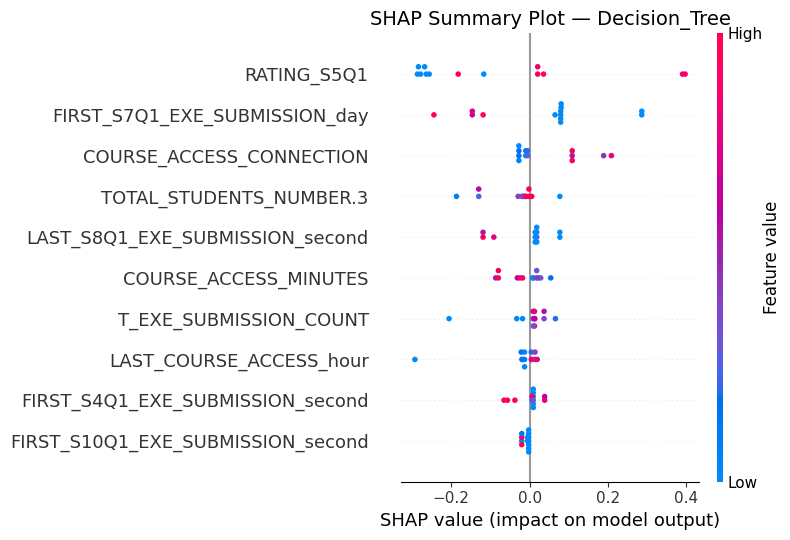


   Bar Plot...


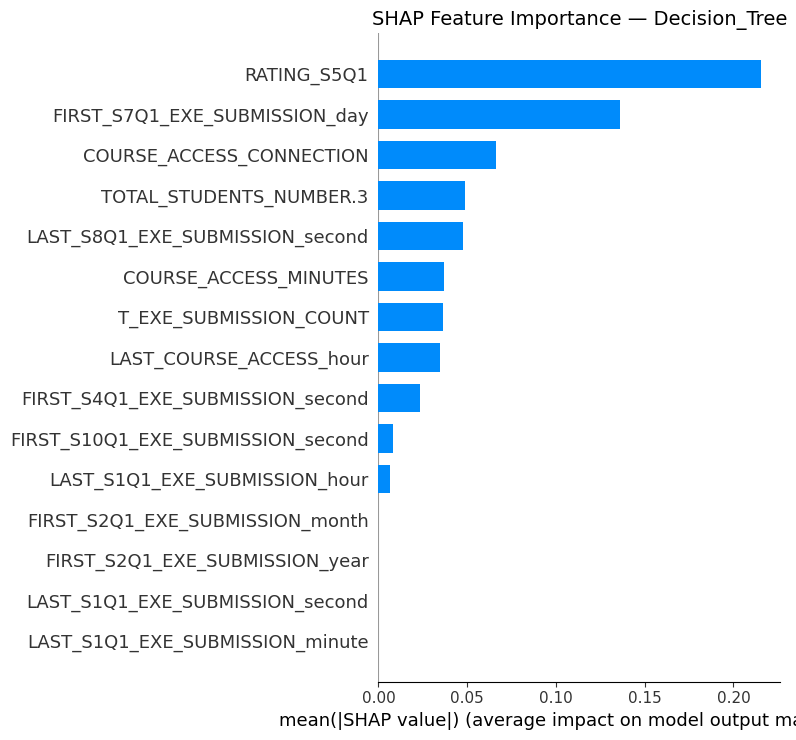


   Waterfall Plots...


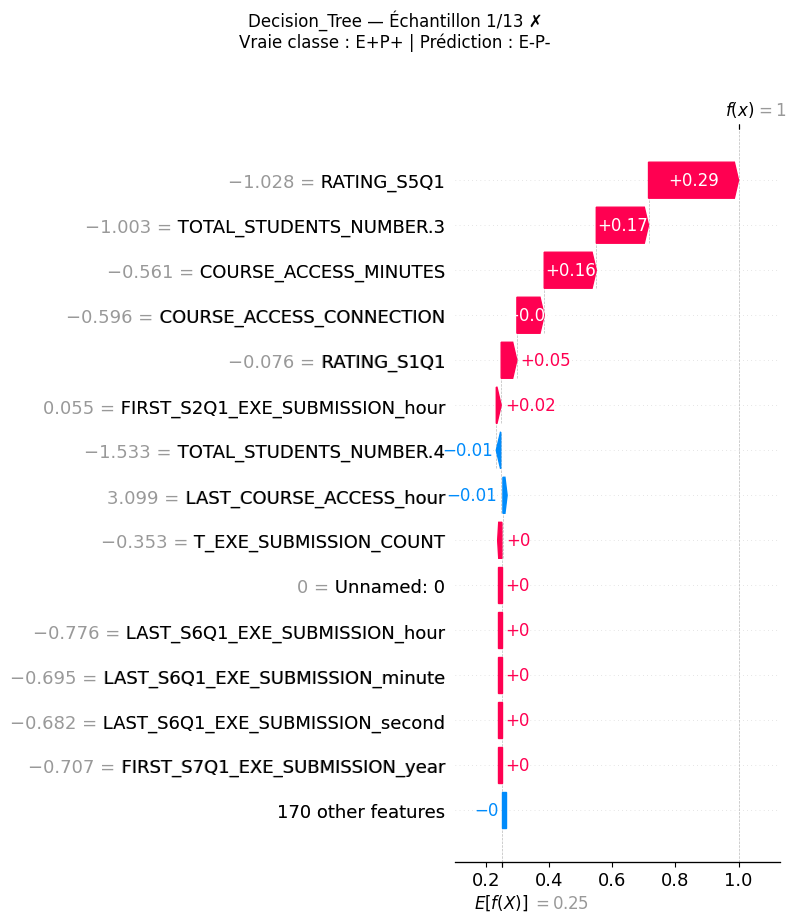

   Échantillon 1 : Vraie=E+P+ | Prédit=E-P- ✗


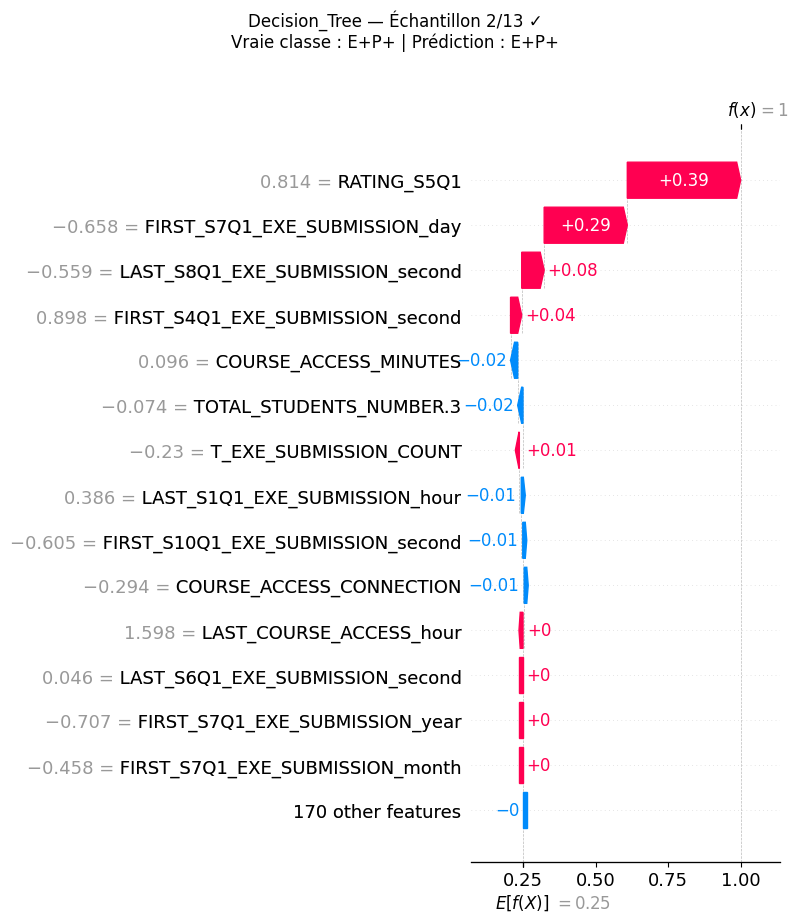

   Échantillon 2 : Vraie=E+P+ | Prédit=E+P+ ✓


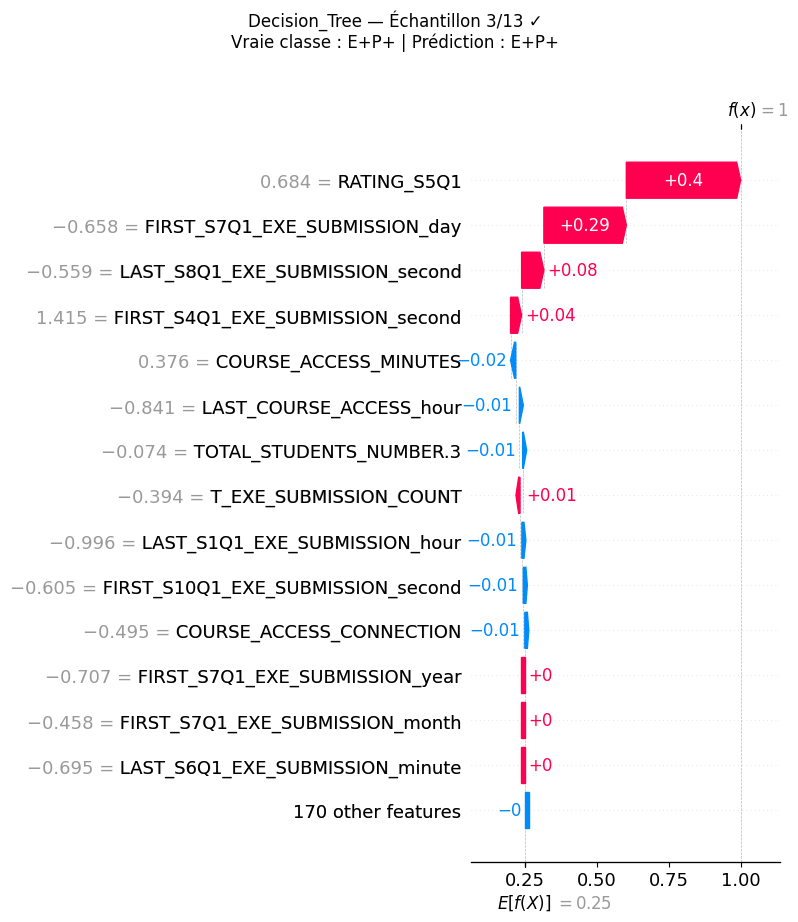

   Échantillon 3 : Vraie=E+P+ | Prédit=E+P+ ✓


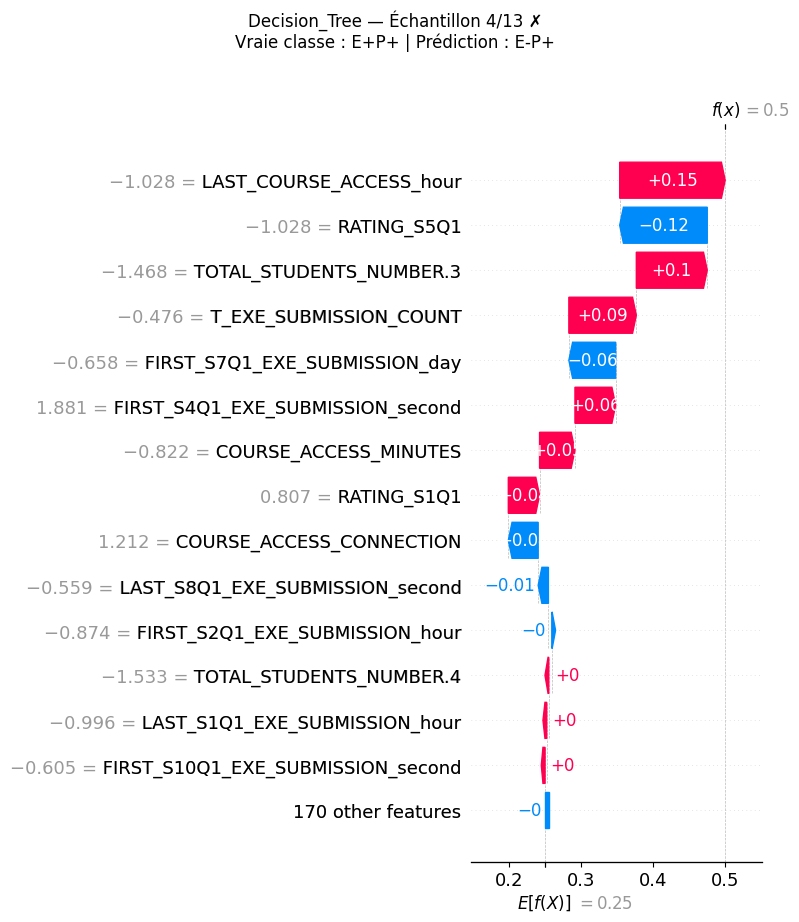

   Échantillon 4 : Vraie=E+P+ | Prédit=E-P+ ✗


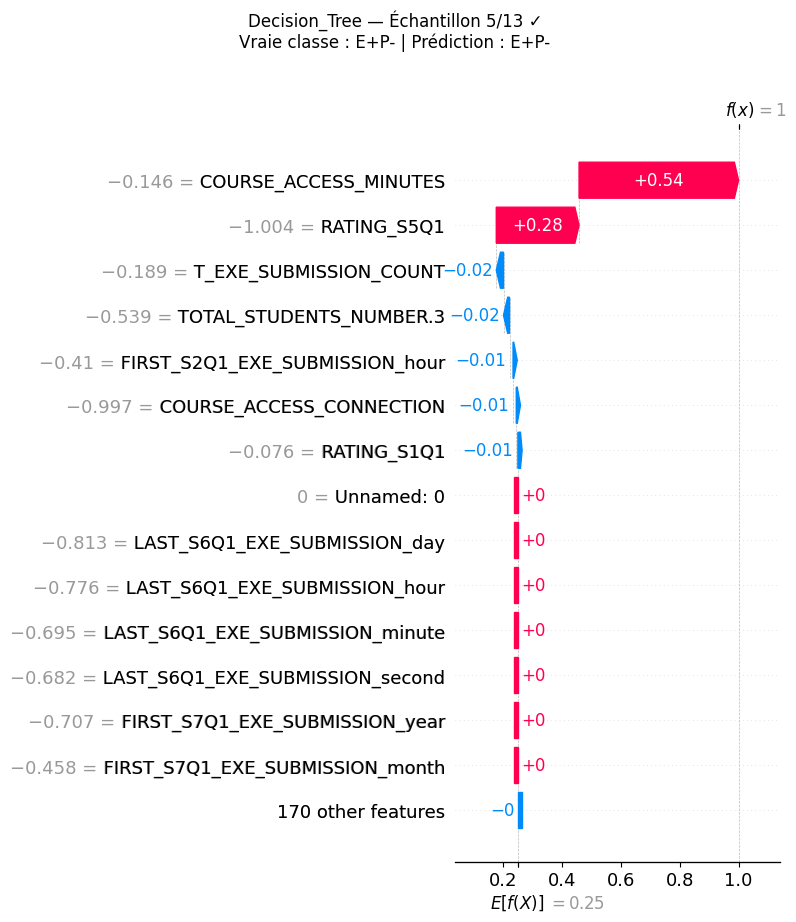

   Échantillon 5 : Vraie=E+P- | Prédit=E+P- ✓


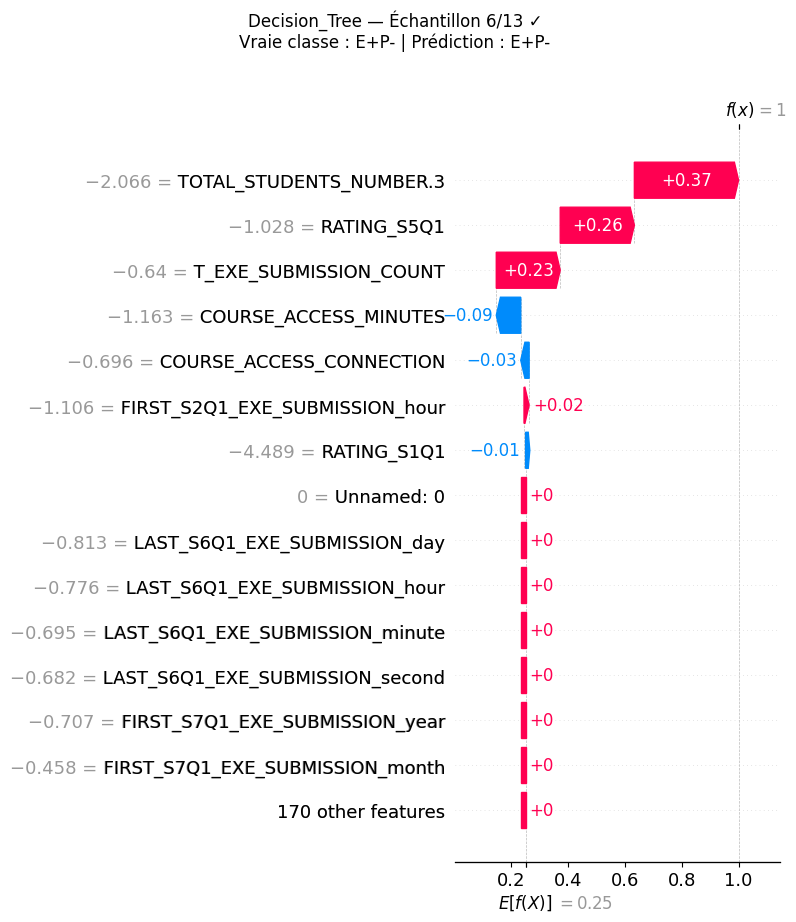

   Échantillon 6 : Vraie=E+P- | Prédit=E+P- ✓


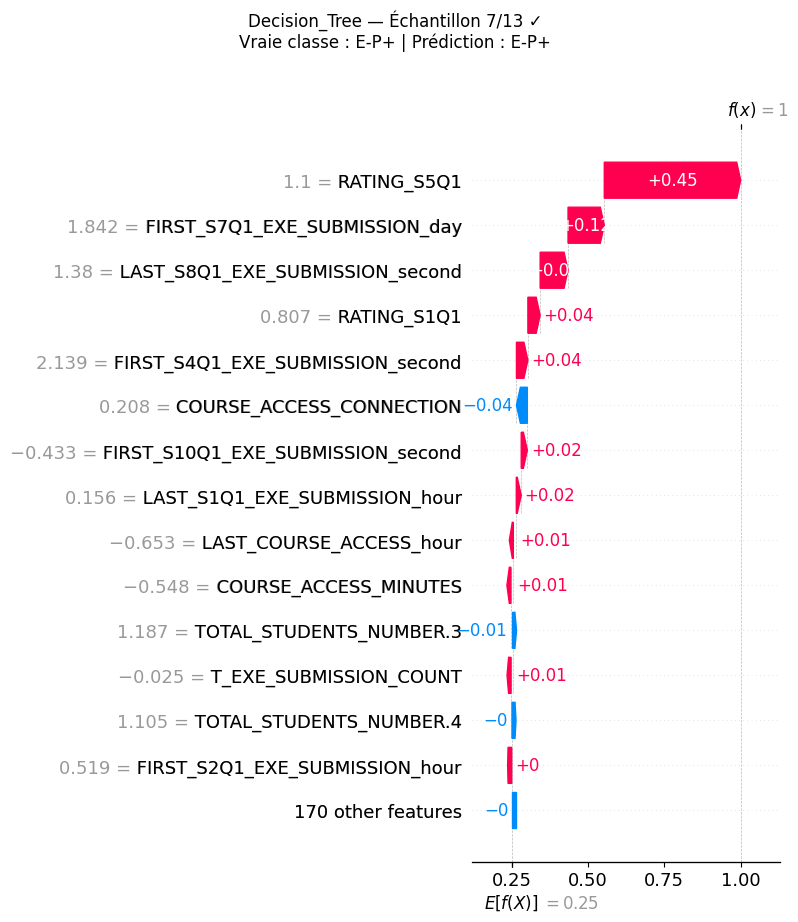

   Échantillon 7 : Vraie=E-P+ | Prédit=E-P+ ✓


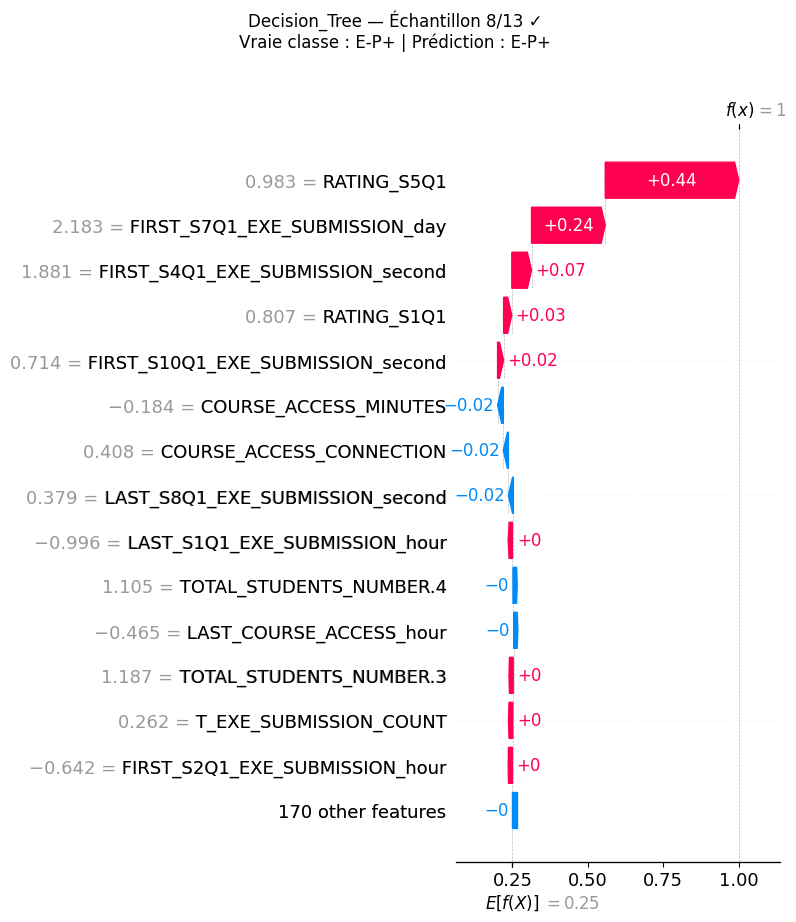

   Échantillon 8 : Vraie=E-P+ | Prédit=E-P+ ✓


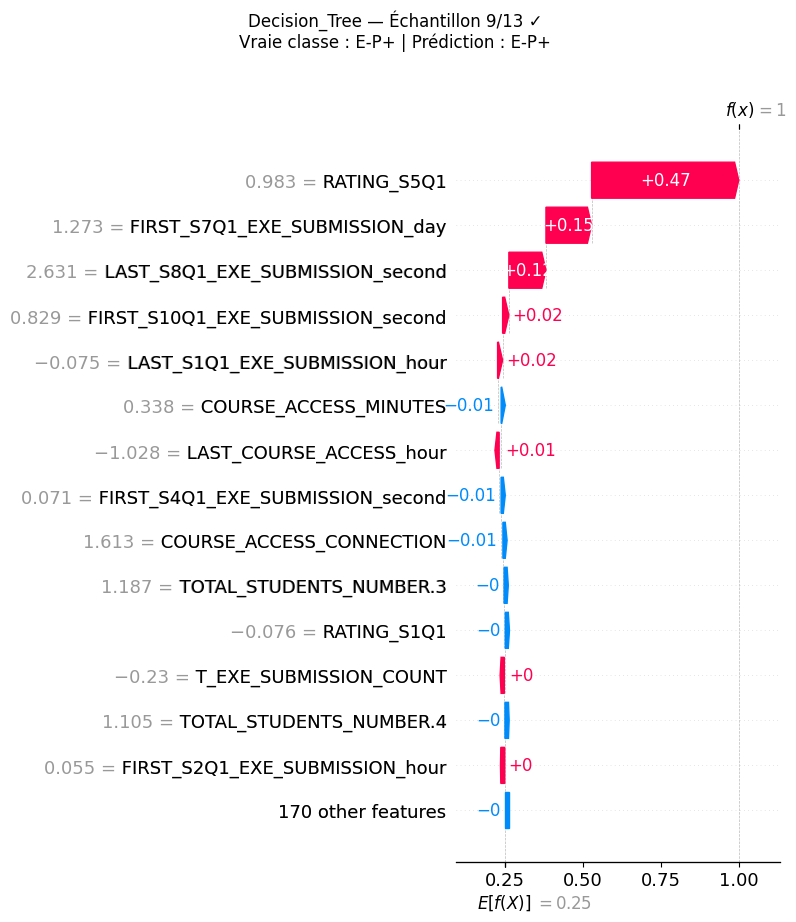

   Échantillon 9 : Vraie=E-P+ | Prédit=E-P+ ✓


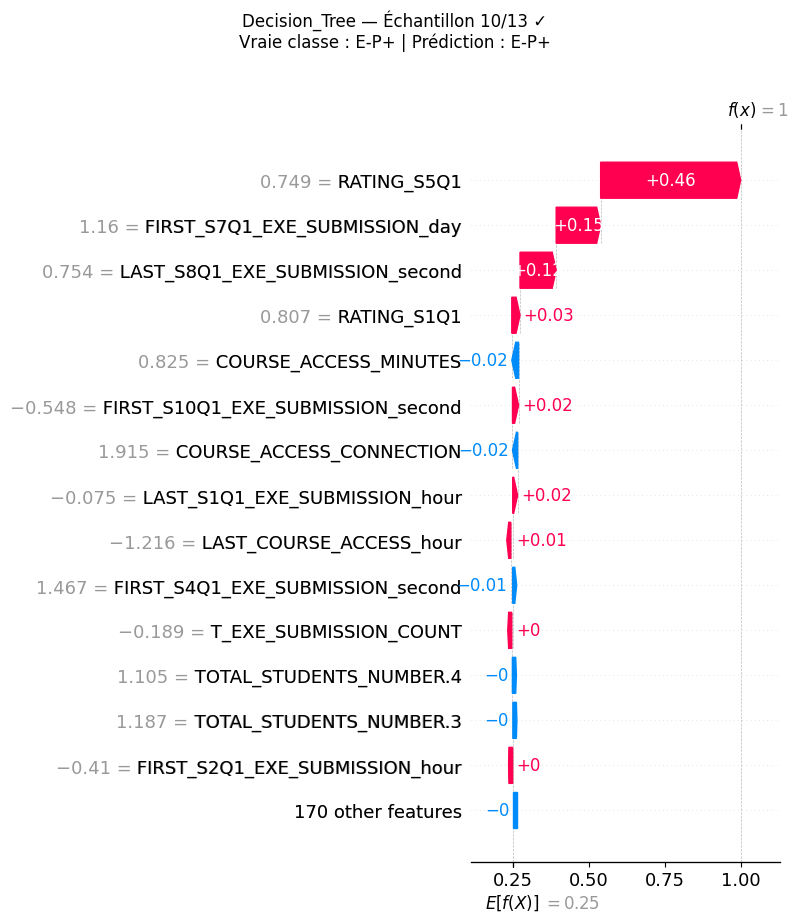

   Échantillon 10 : Vraie=E-P+ | Prédit=E-P+ ✓


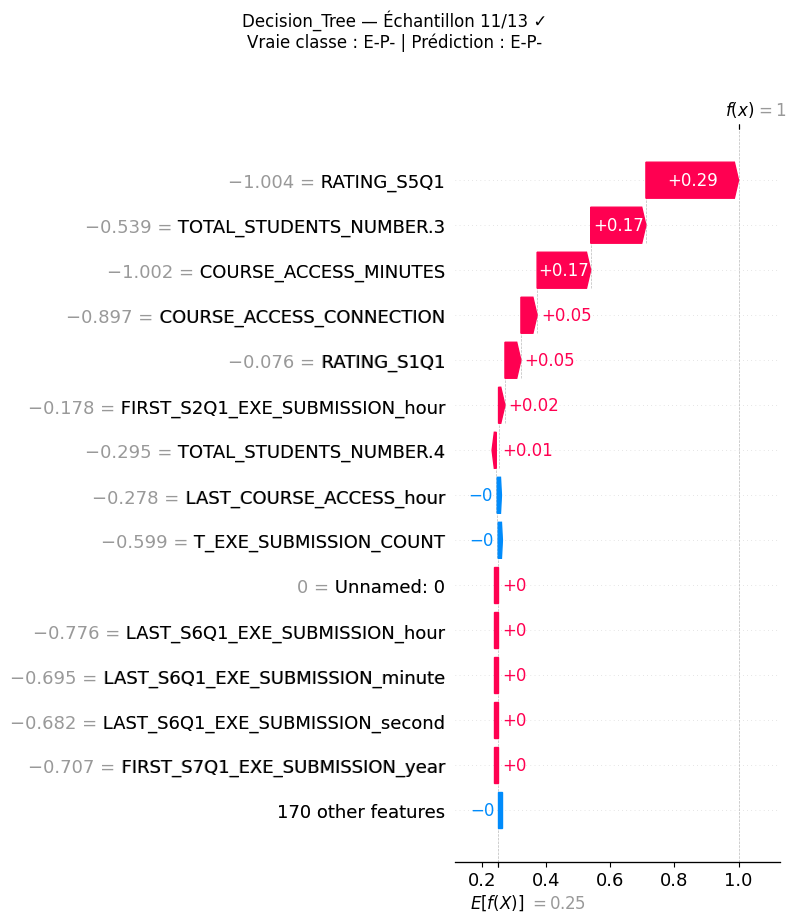

   Échantillon 11 : Vraie=E-P- | Prédit=E-P- ✓


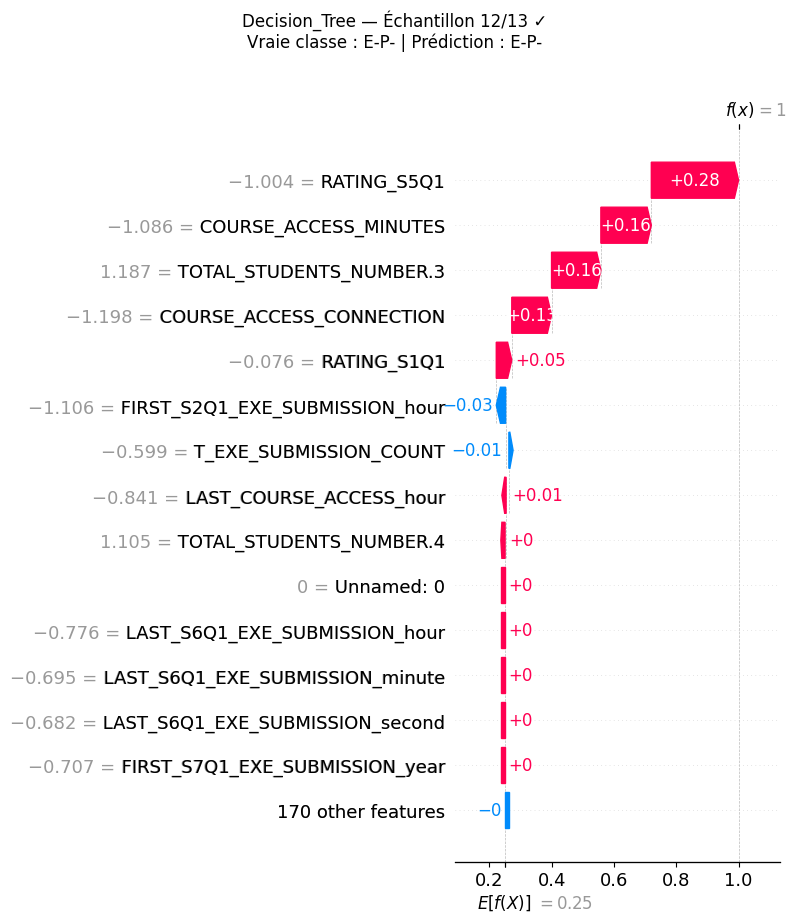

   Échantillon 12 : Vraie=E-P- | Prédit=E-P- ✓


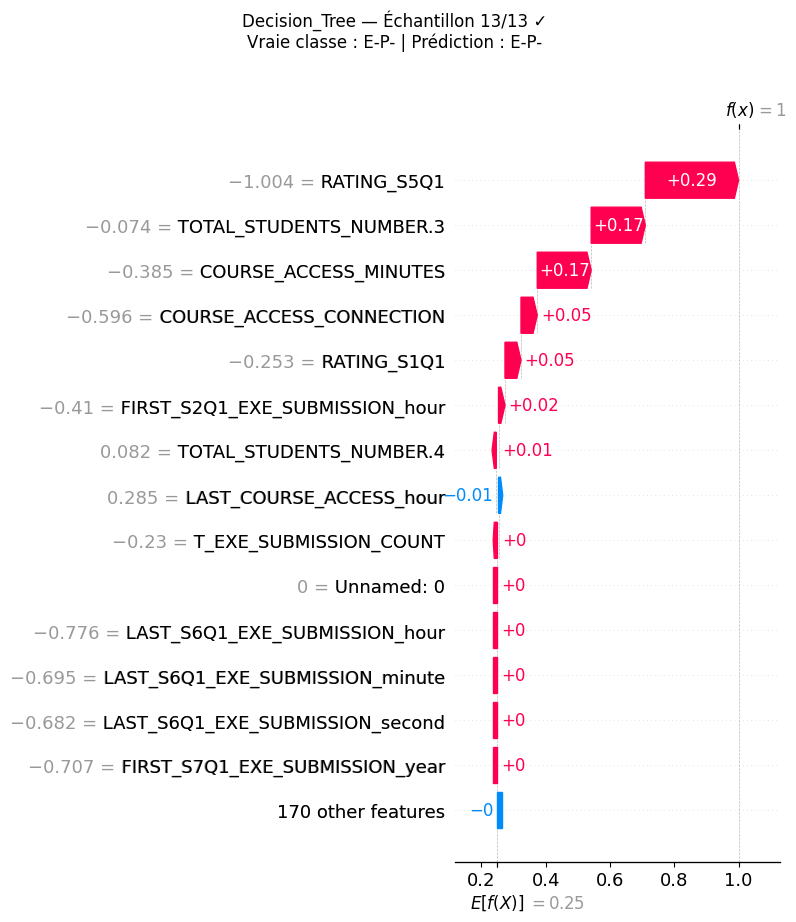

   Échantillon 13 : Vraie=E-P- | Prédit=E-P- ✓

 GRAPHIQUES SHAP — Random_Forest

   Summary Plot...


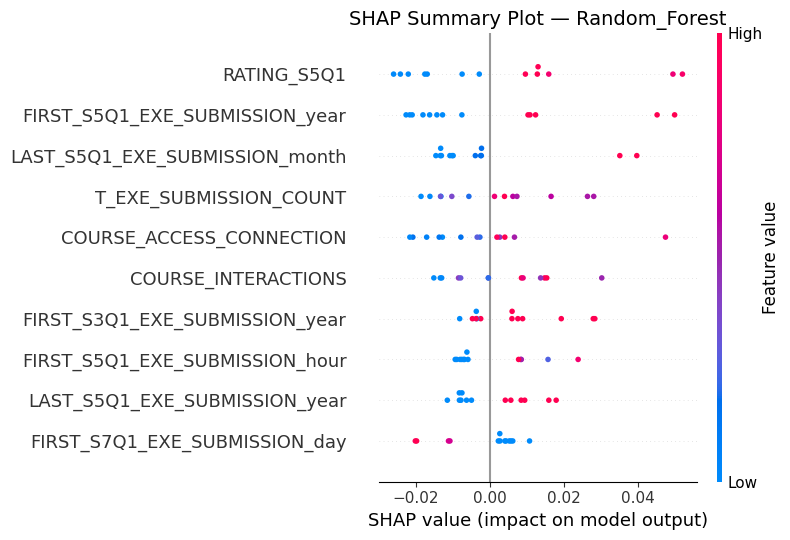


   Bar Plot...


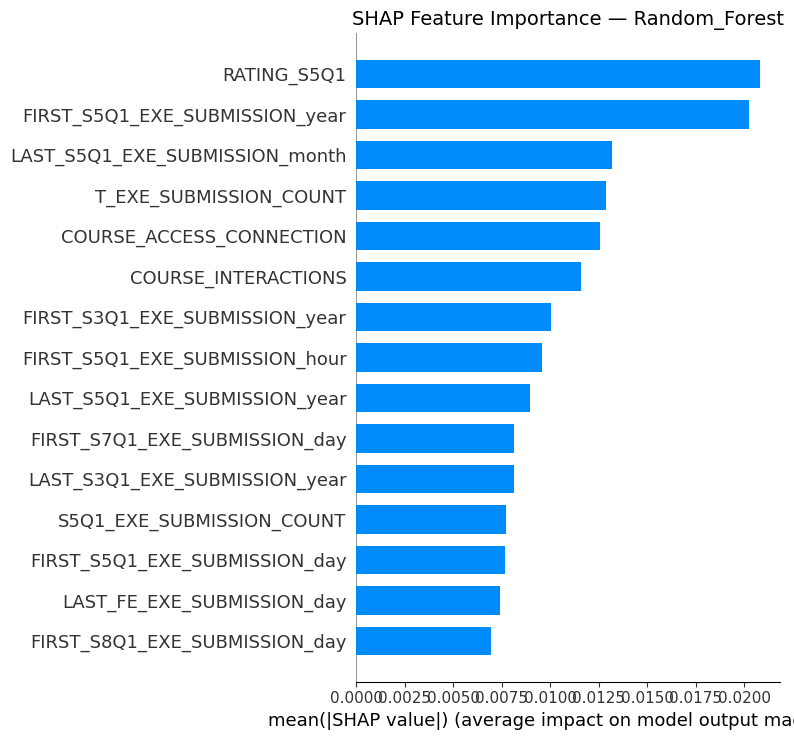


   Waterfall Plots...


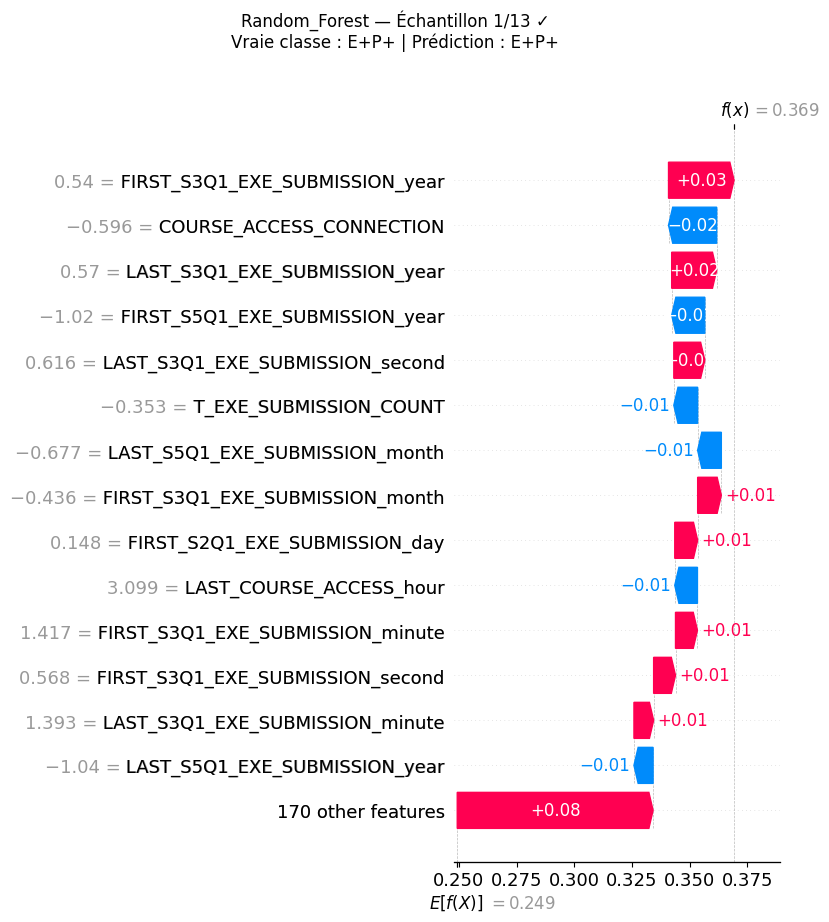

   Échantillon 1 : Vraie=E+P+ | Prédit=E+P+ ✓


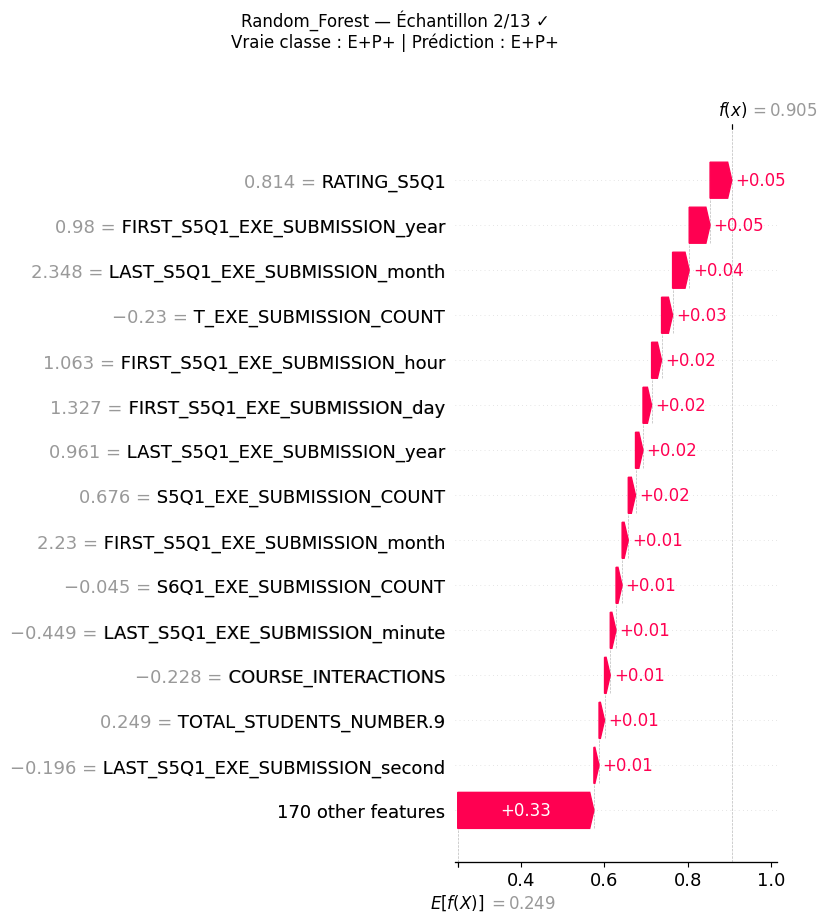

   Échantillon 2 : Vraie=E+P+ | Prédit=E+P+ ✓


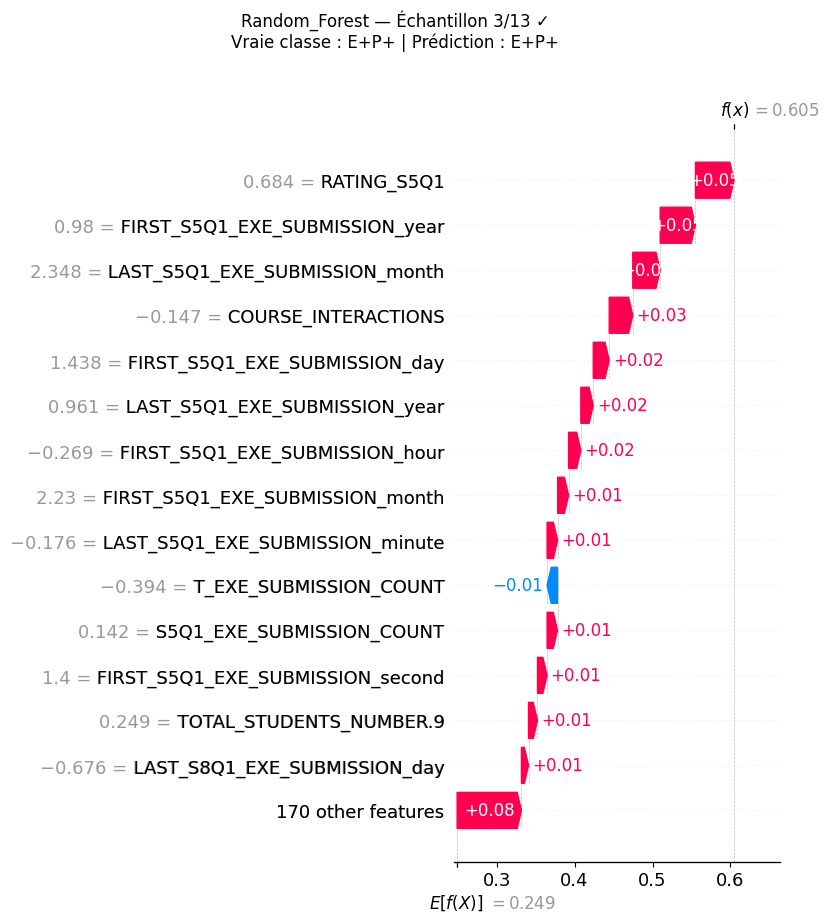

   Échantillon 3 : Vraie=E+P+ | Prédit=E+P+ ✓


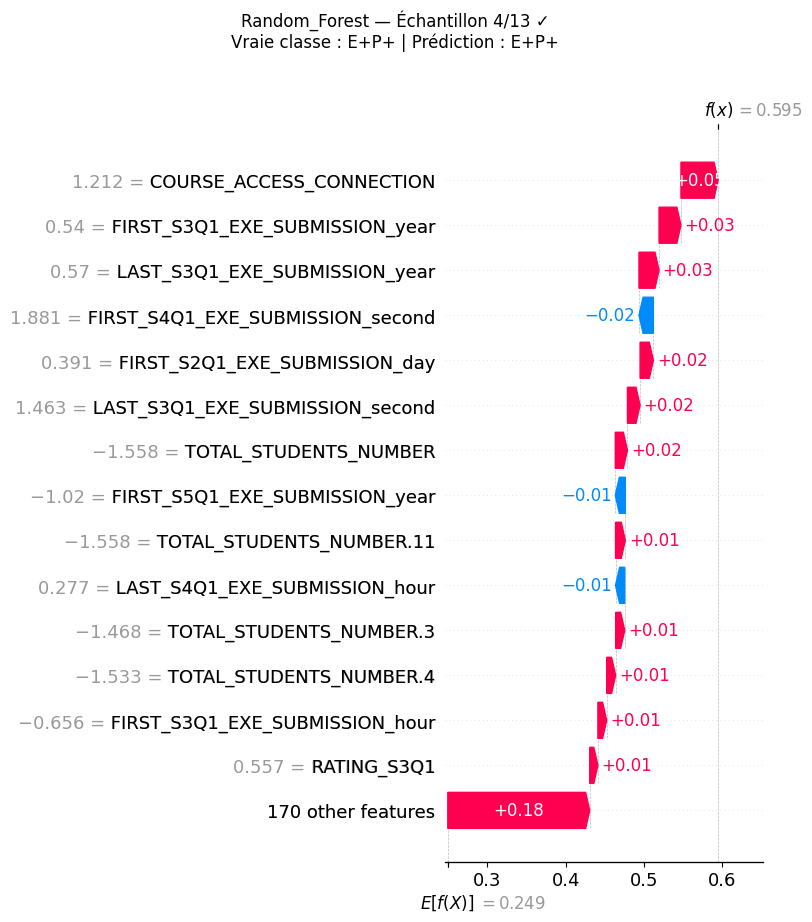

   Échantillon 4 : Vraie=E+P+ | Prédit=E+P+ ✓


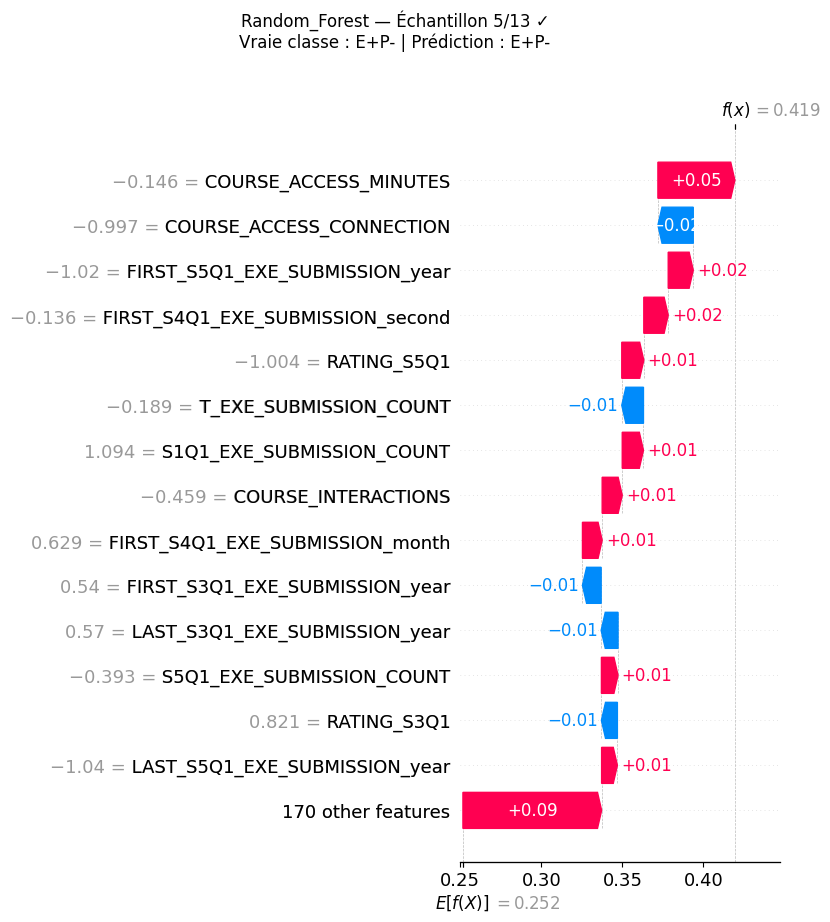

   Échantillon 5 : Vraie=E+P- | Prédit=E+P- ✓


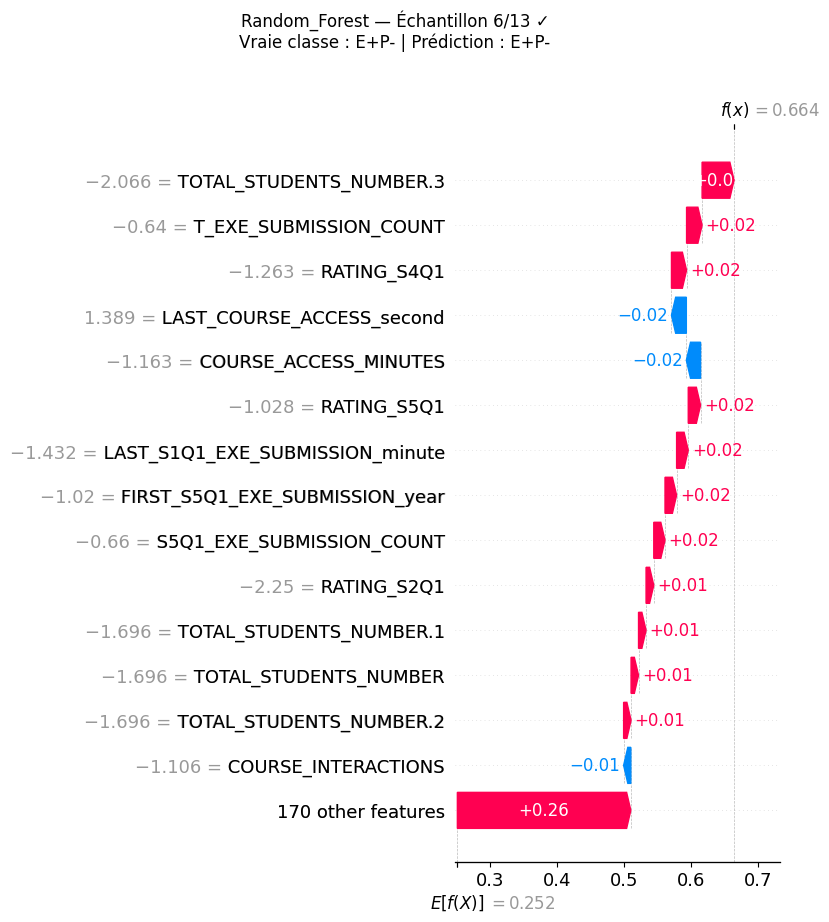

   Échantillon 6 : Vraie=E+P- | Prédit=E+P- ✓


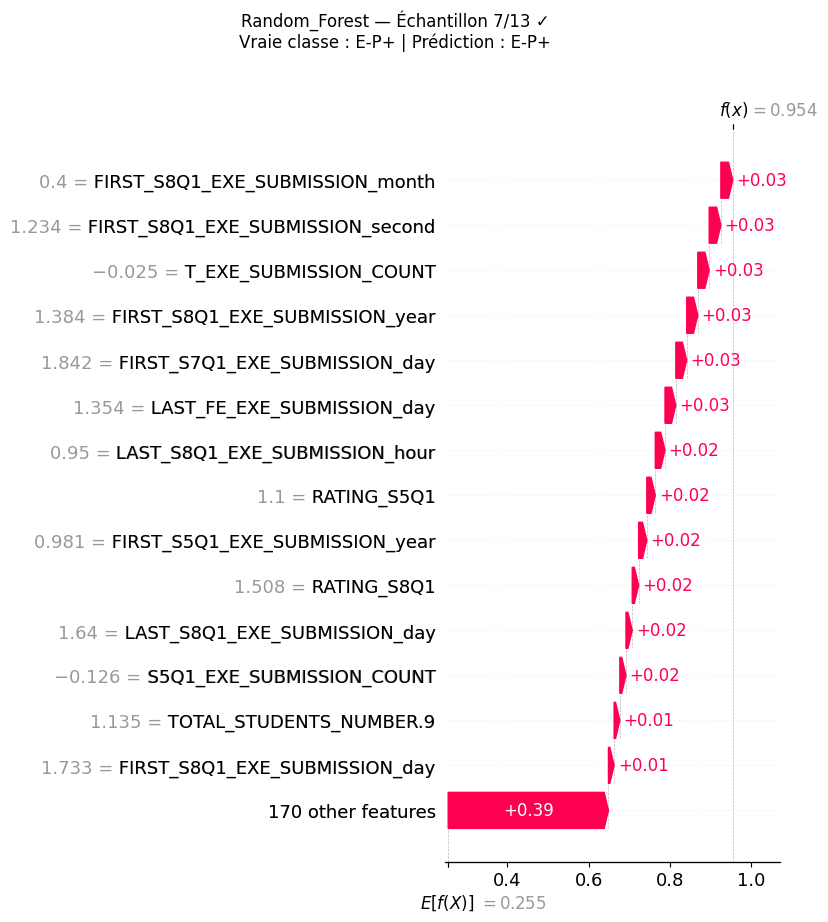

   Échantillon 7 : Vraie=E-P+ | Prédit=E-P+ ✓


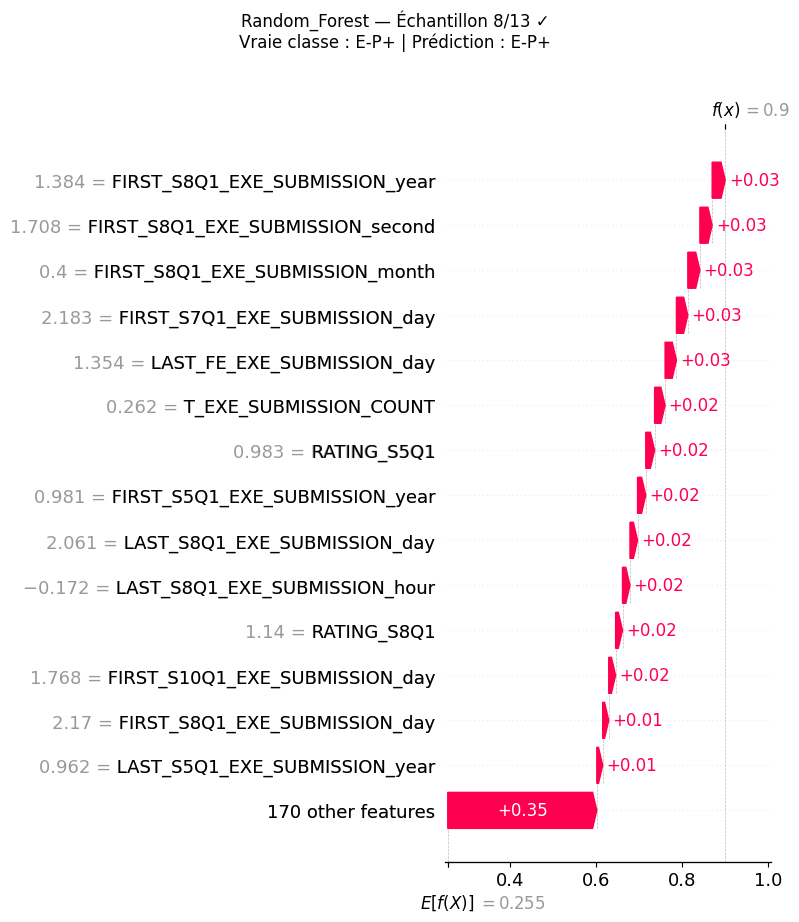

   Échantillon 8 : Vraie=E-P+ | Prédit=E-P+ ✓


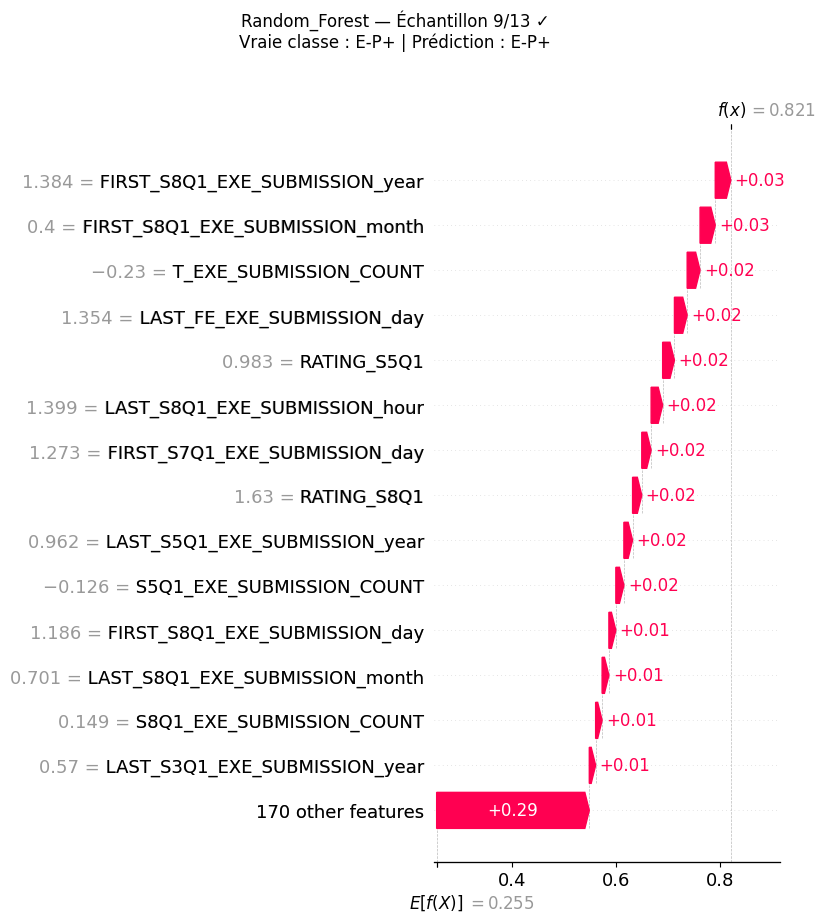

   Échantillon 9 : Vraie=E-P+ | Prédit=E-P+ ✓


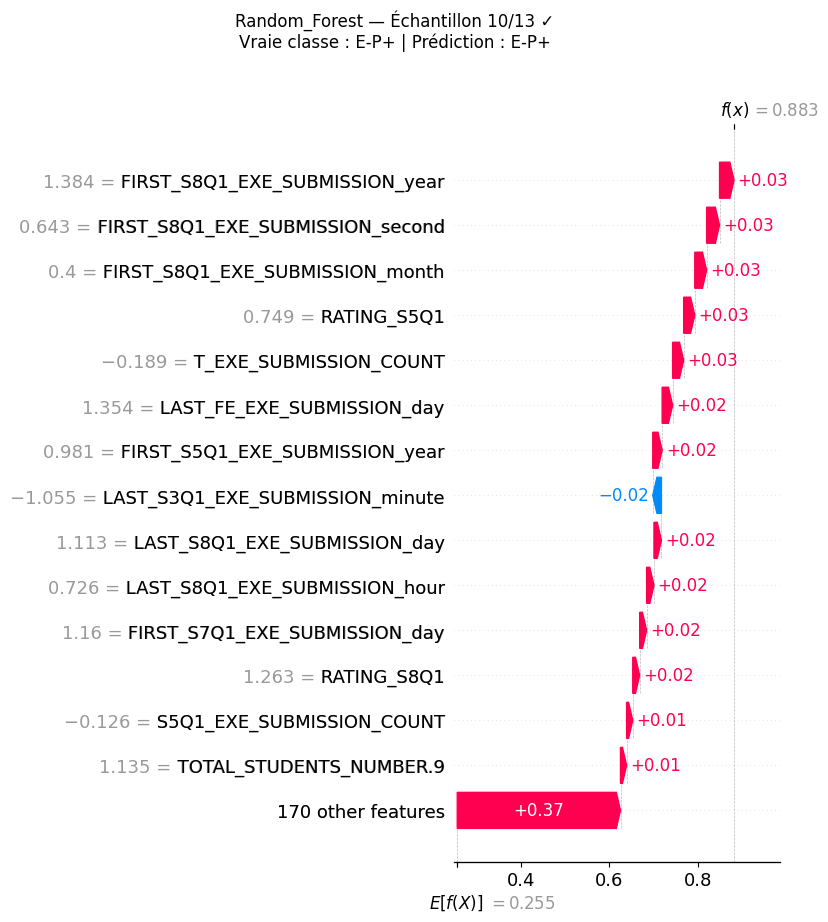

   Échantillon 10 : Vraie=E-P+ | Prédit=E-P+ ✓


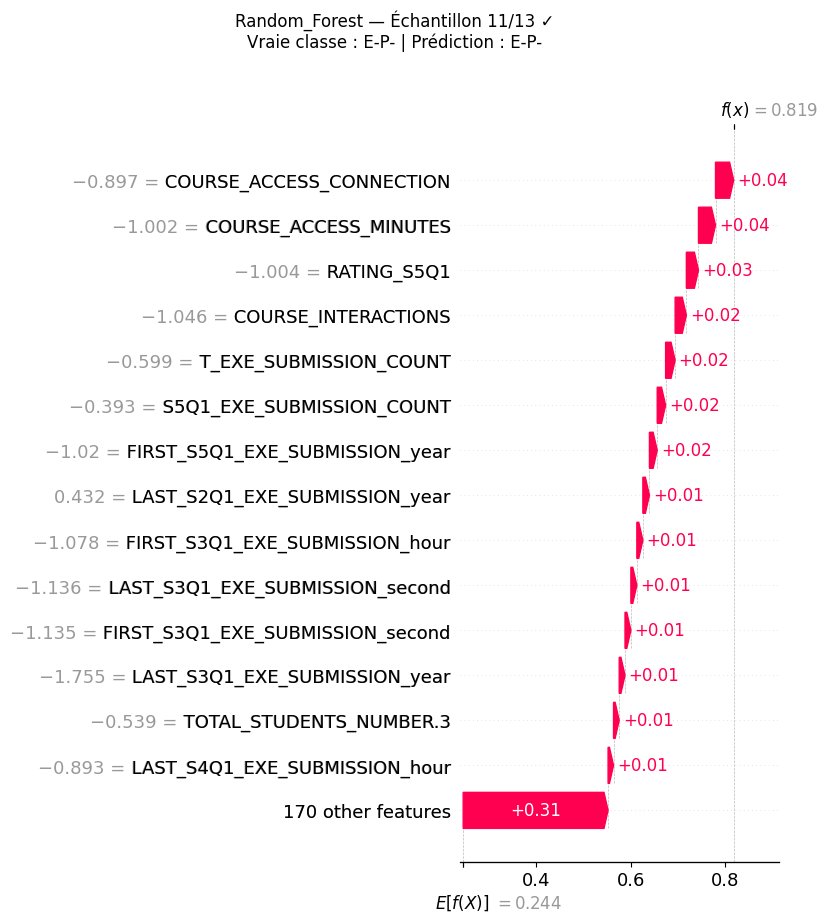

   Échantillon 11 : Vraie=E-P- | Prédit=E-P- ✓


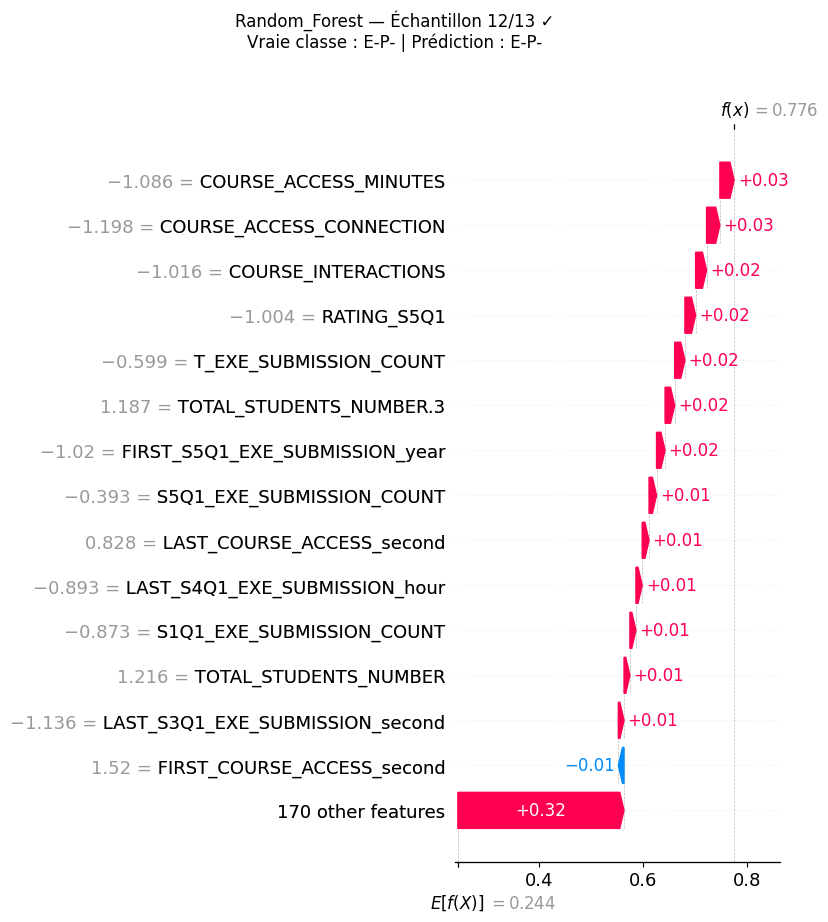

   Échantillon 12 : Vraie=E-P- | Prédit=E-P- ✓


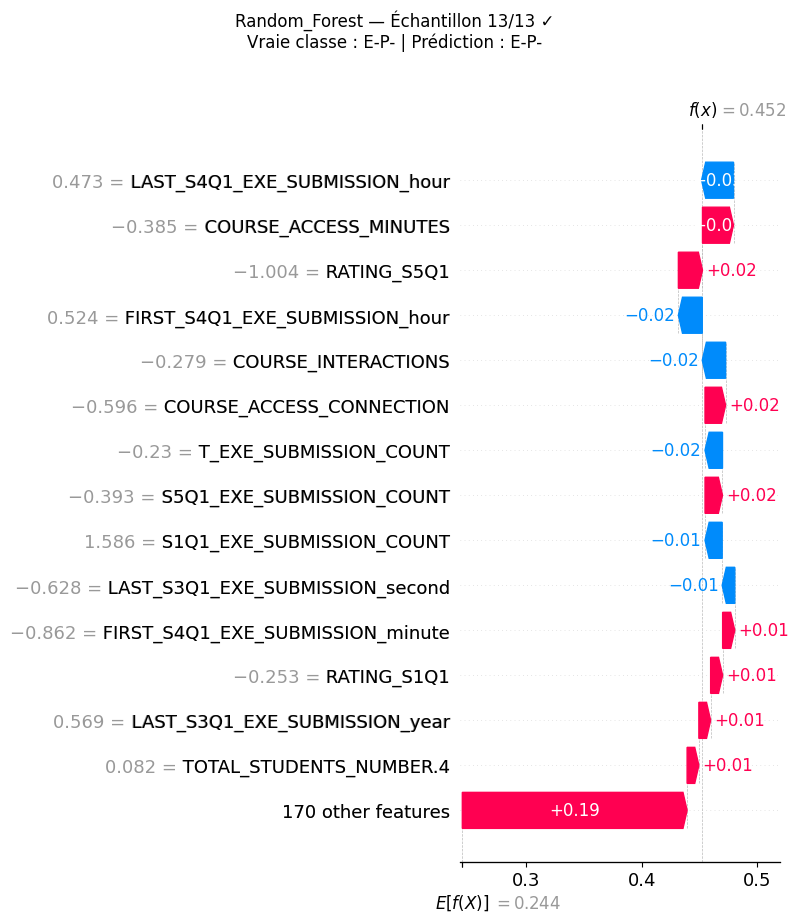

   Échantillon 13 : Vraie=E-P- | Prédit=E-P- ✓

 GRAPHIQUES SHAP — XGBoost

   Summary Plot...


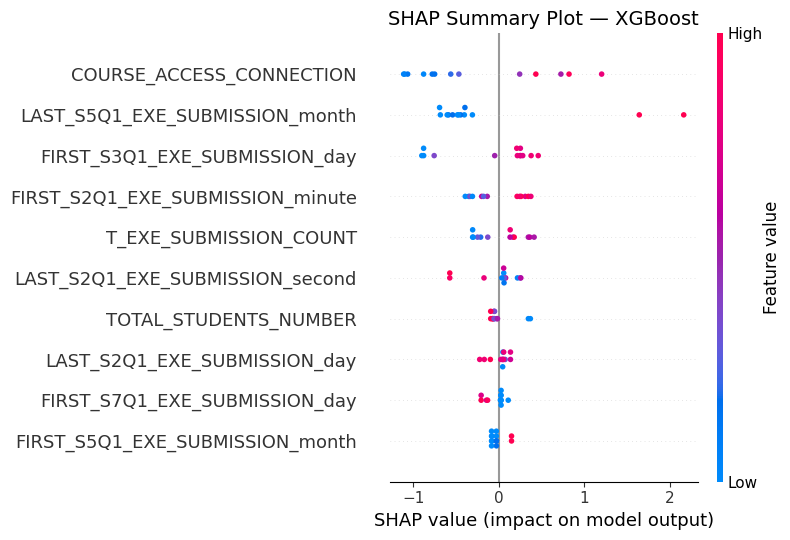


   Bar Plot...


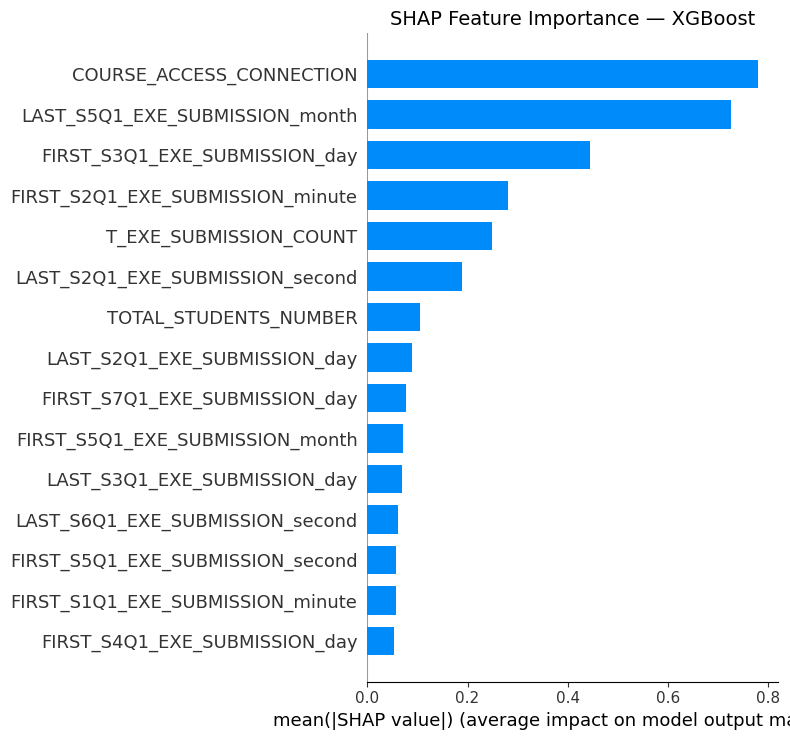


   Waterfall Plots...


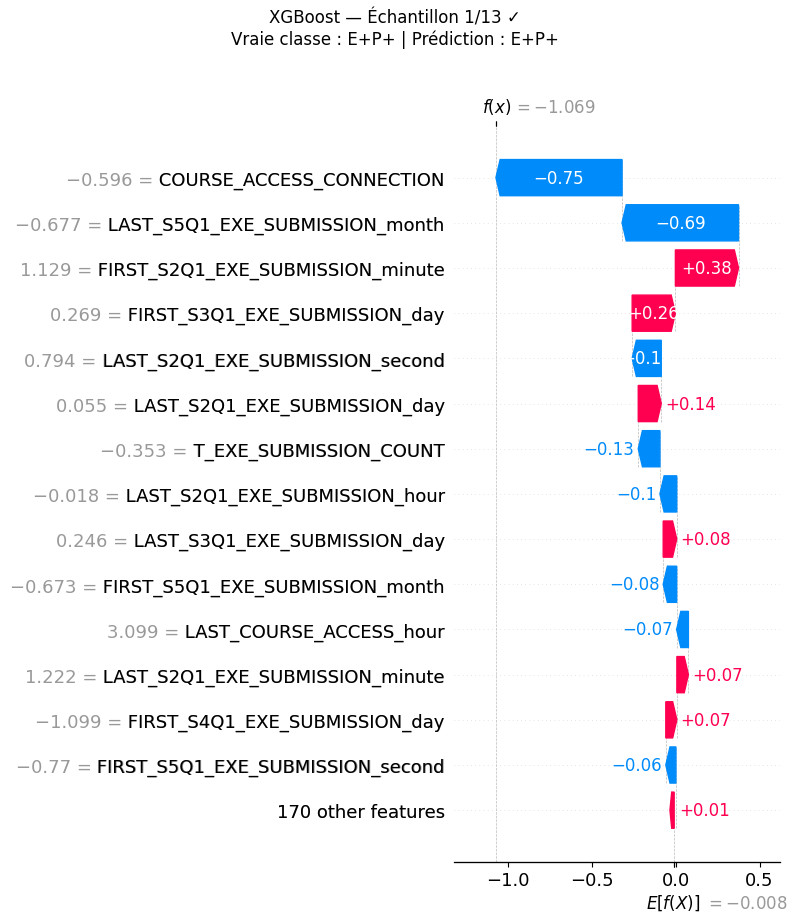

   Échantillon 1 : Vraie=E+P+ | Prédit=E+P+ ✓


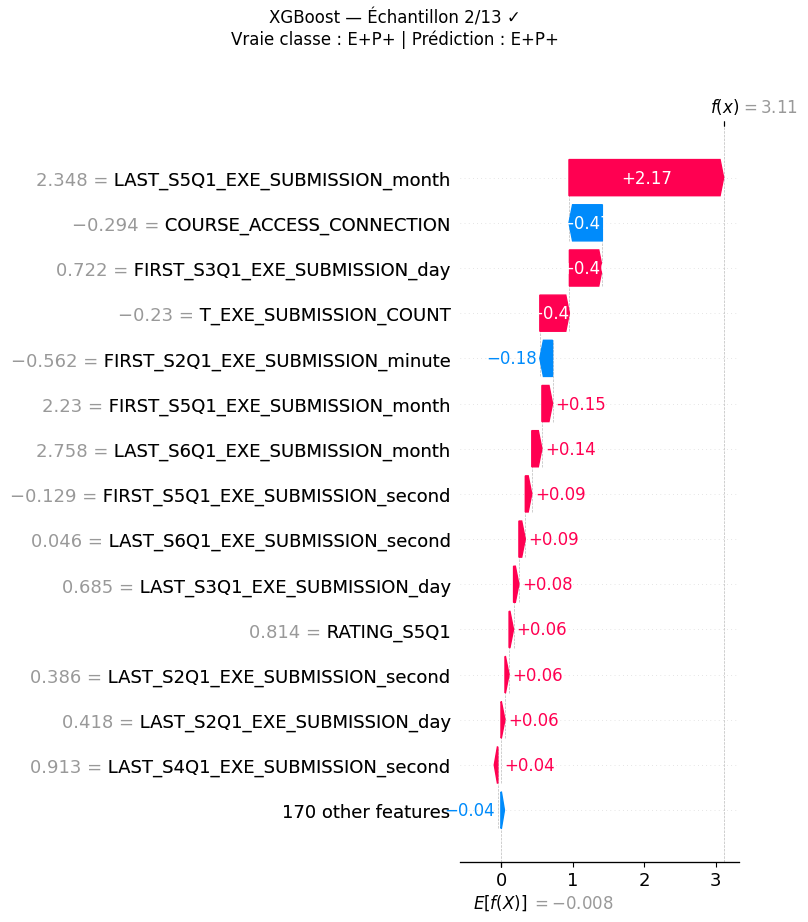

   Échantillon 2 : Vraie=E+P+ | Prédit=E+P+ ✓


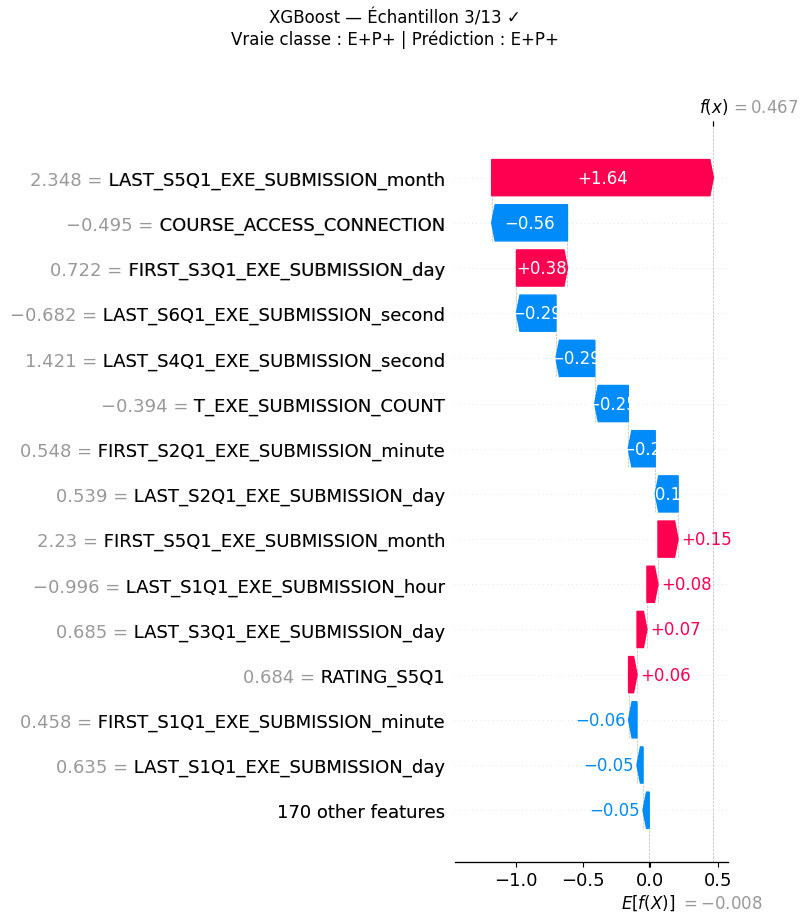

   Échantillon 3 : Vraie=E+P+ | Prédit=E+P+ ✓


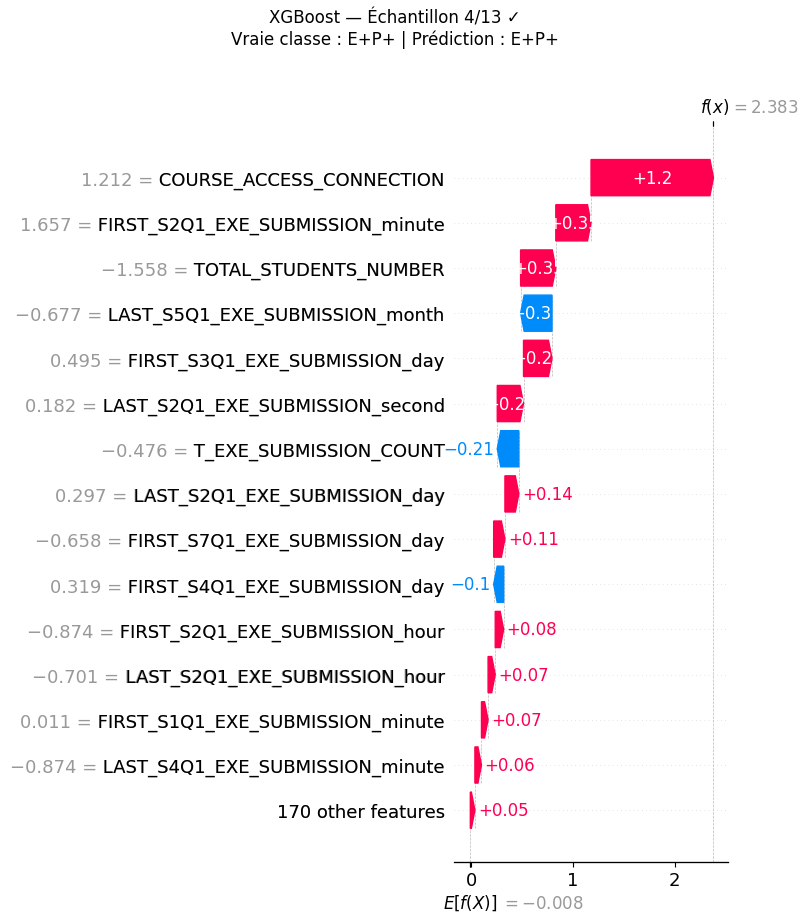

   Échantillon 4 : Vraie=E+P+ | Prédit=E+P+ ✓


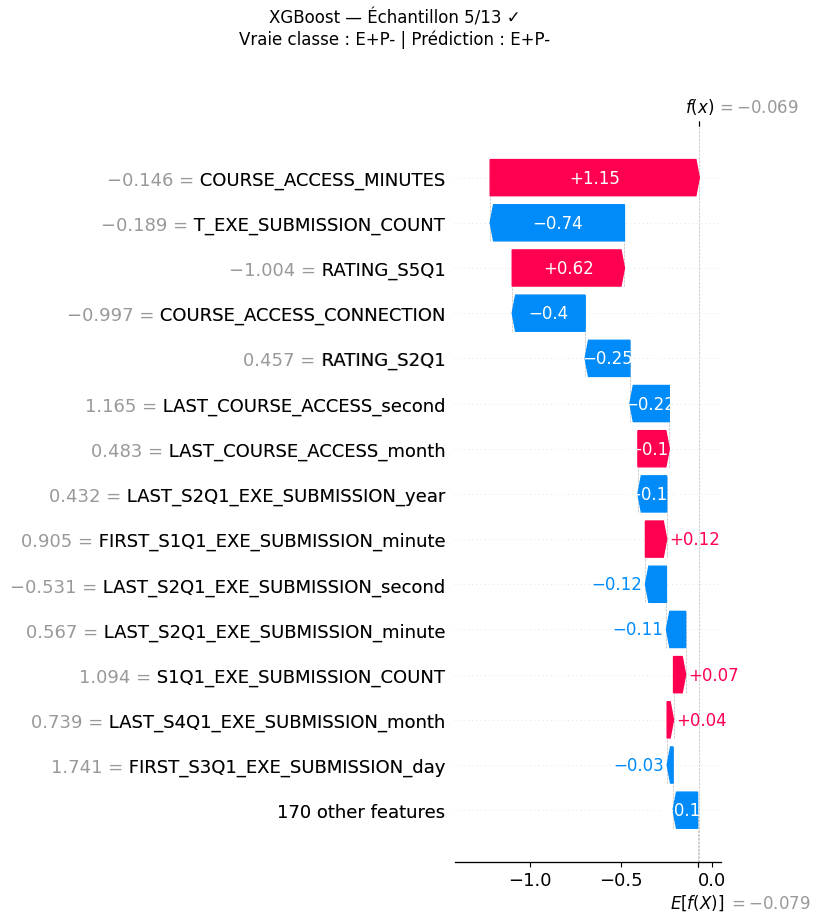

   Échantillon 5 : Vraie=E+P- | Prédit=E+P- ✓


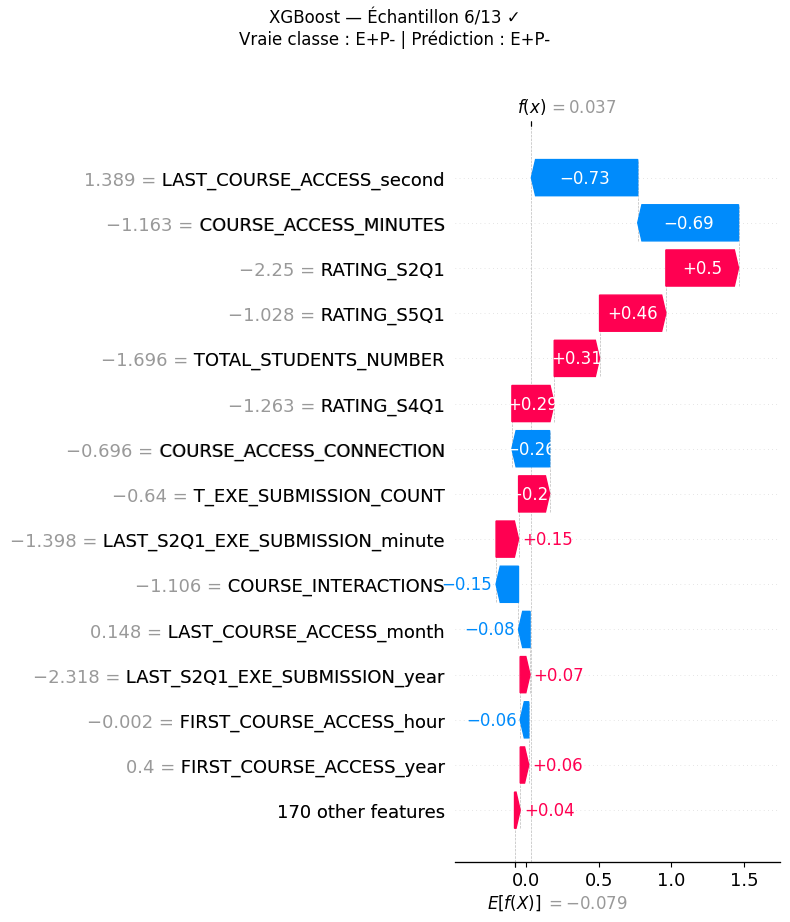

   Échantillon 6 : Vraie=E+P- | Prédit=E+P- ✓


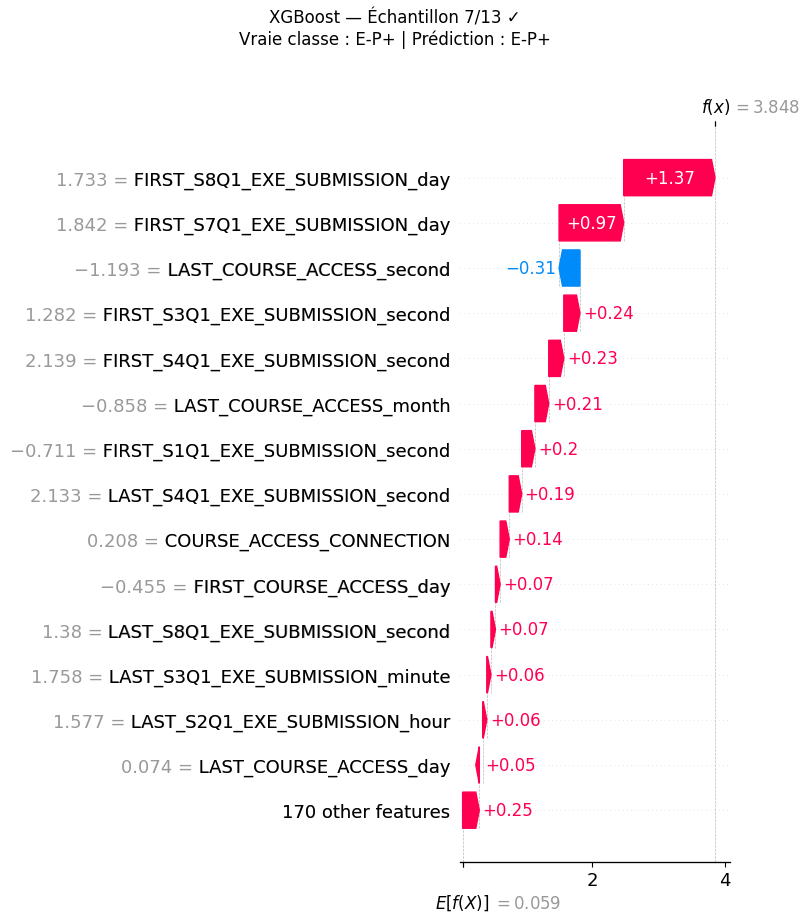

   Échantillon 7 : Vraie=E-P+ | Prédit=E-P+ ✓


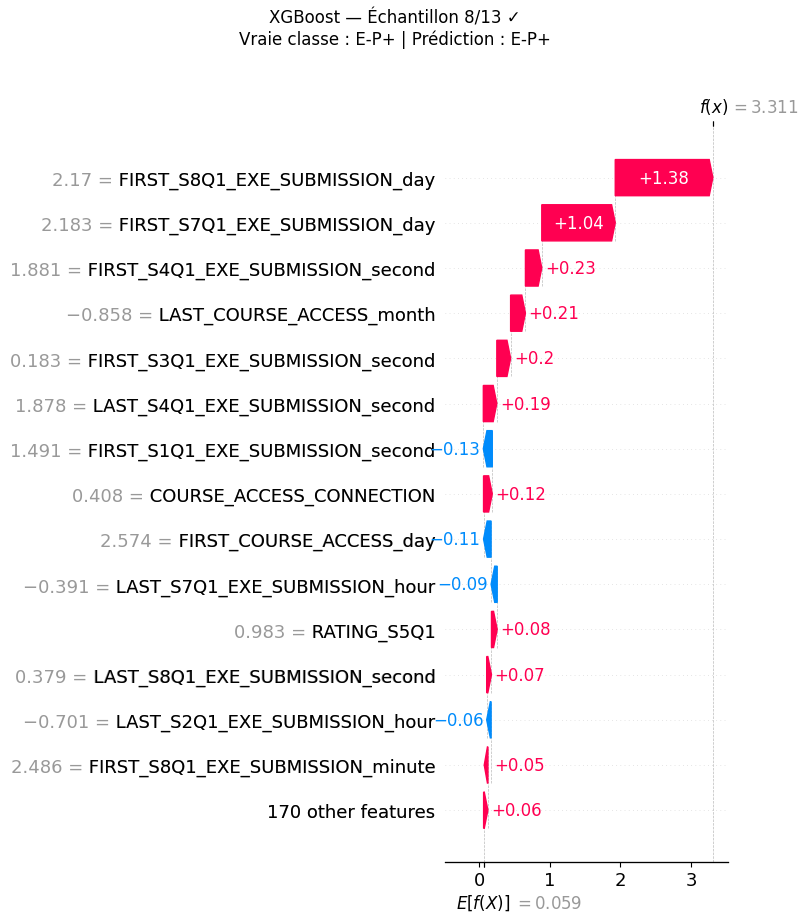

   Échantillon 8 : Vraie=E-P+ | Prédit=E-P+ ✓


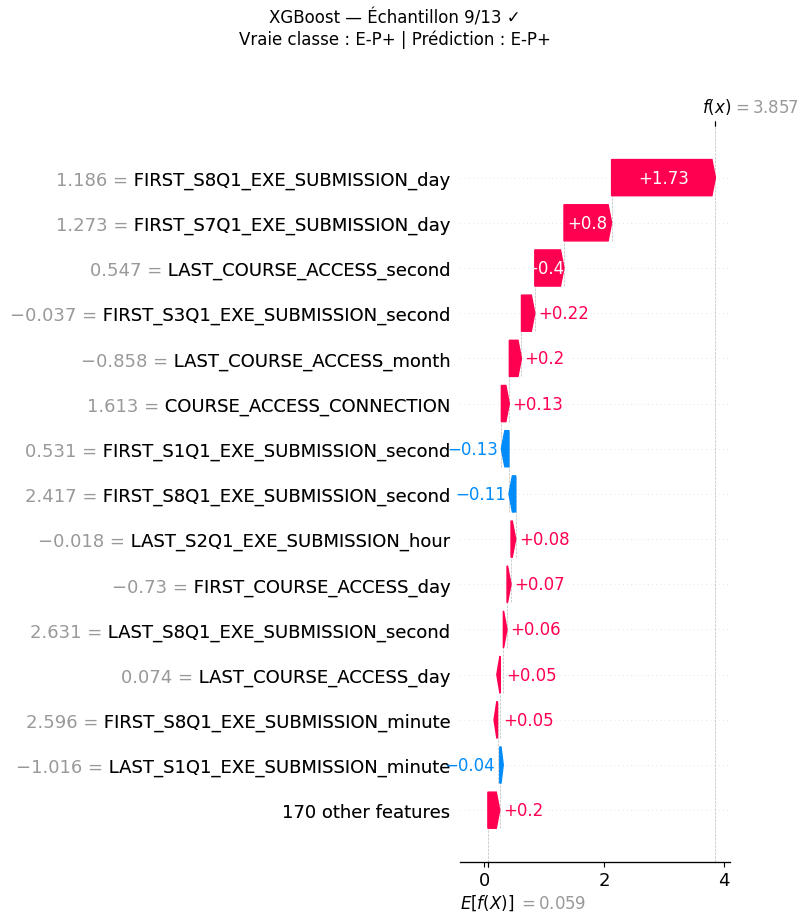

   Échantillon 9 : Vraie=E-P+ | Prédit=E-P+ ✓


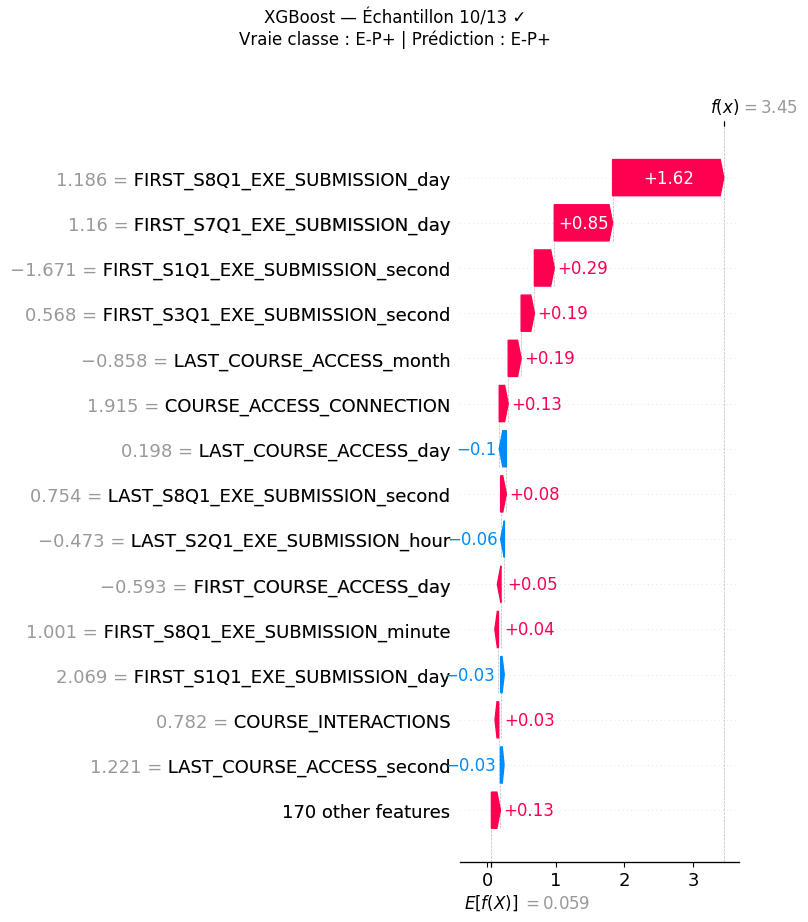

   Échantillon 10 : Vraie=E-P+ | Prédit=E-P+ ✓


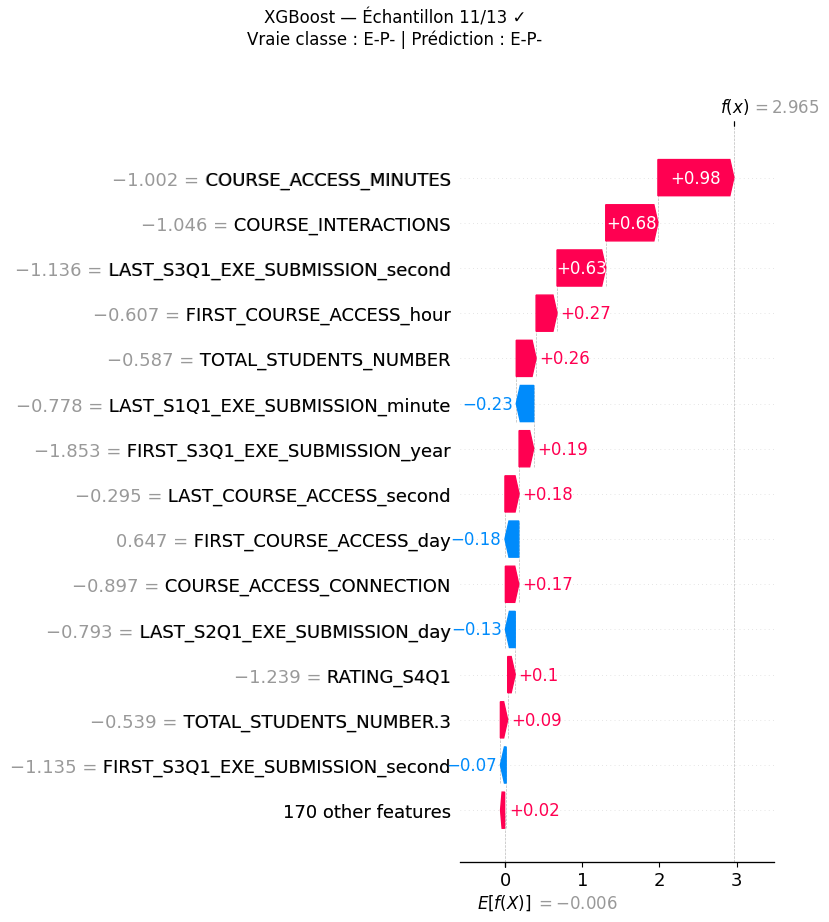

   Échantillon 11 : Vraie=E-P- | Prédit=E-P- ✓


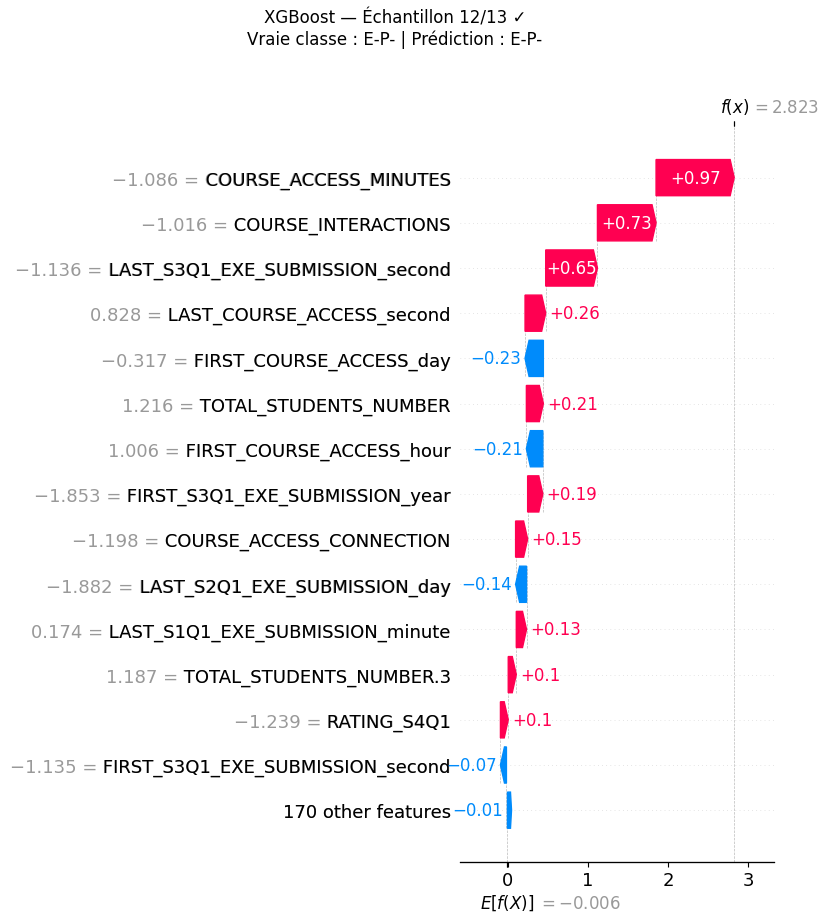

   Échantillon 12 : Vraie=E-P- | Prédit=E-P- ✓


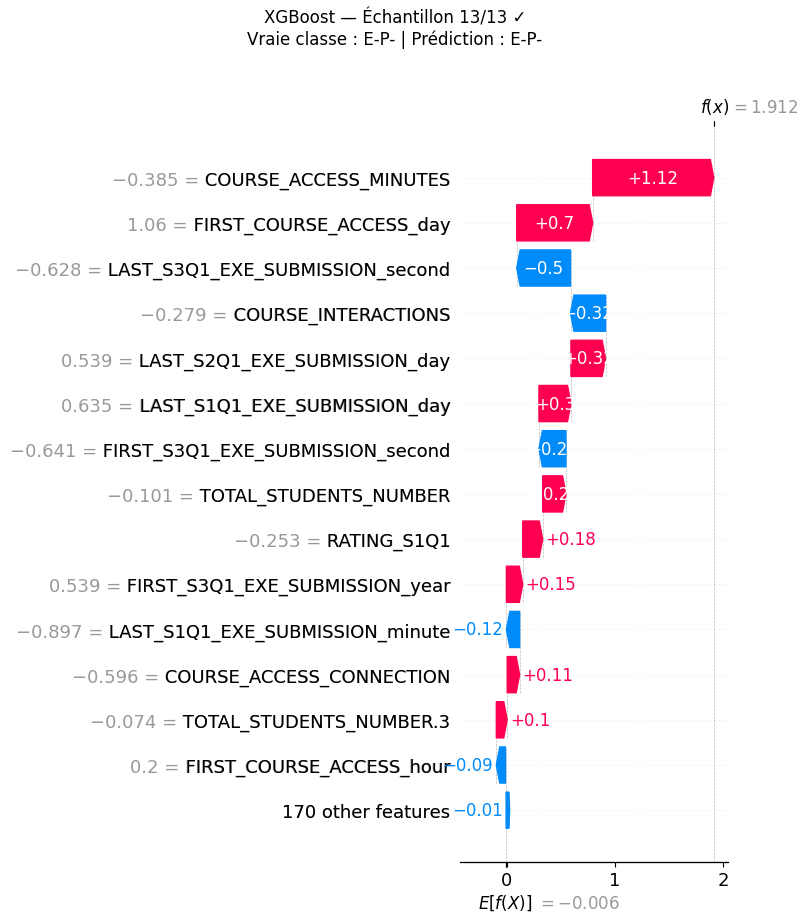

   Échantillon 13 : Vraie=E-P- | Prédit=E-P- ✓

 COMPARAISON SHAP ENTRE MODÈLES

   Heatmap de comparaison...


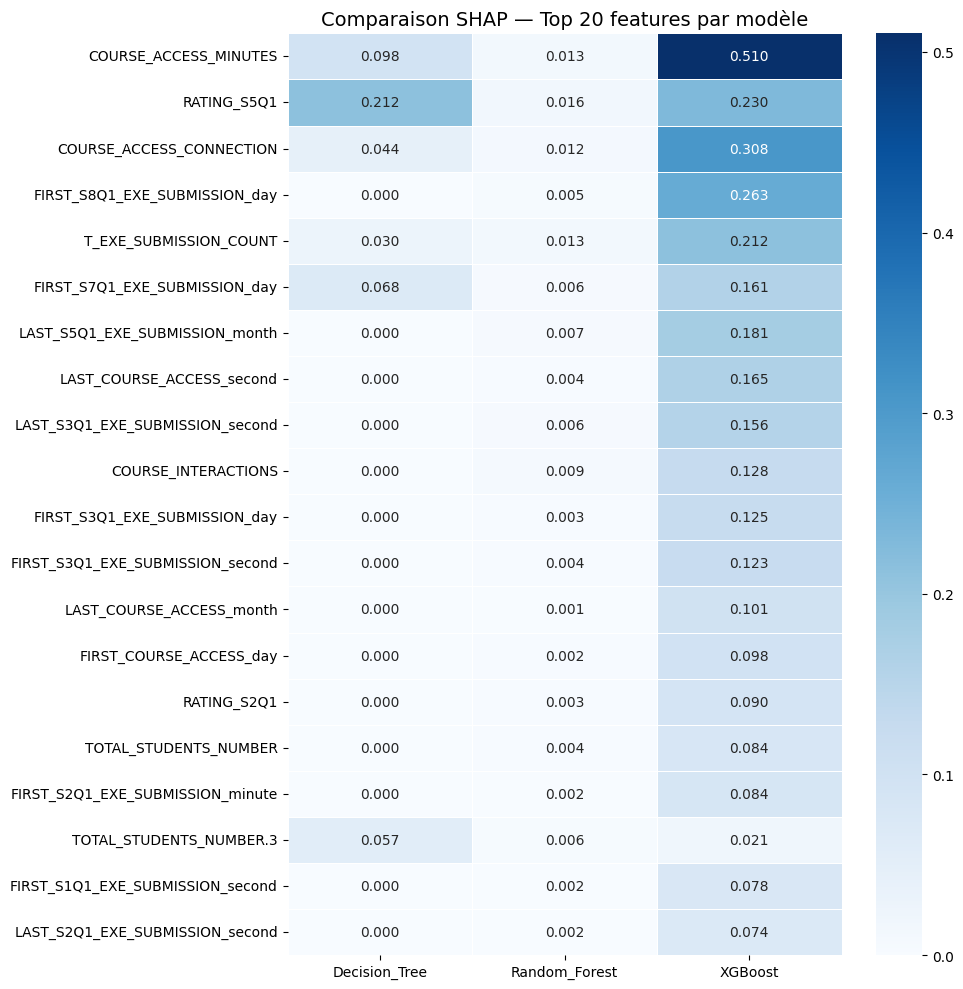


   Top 10 features (moyenne tous modèles)...


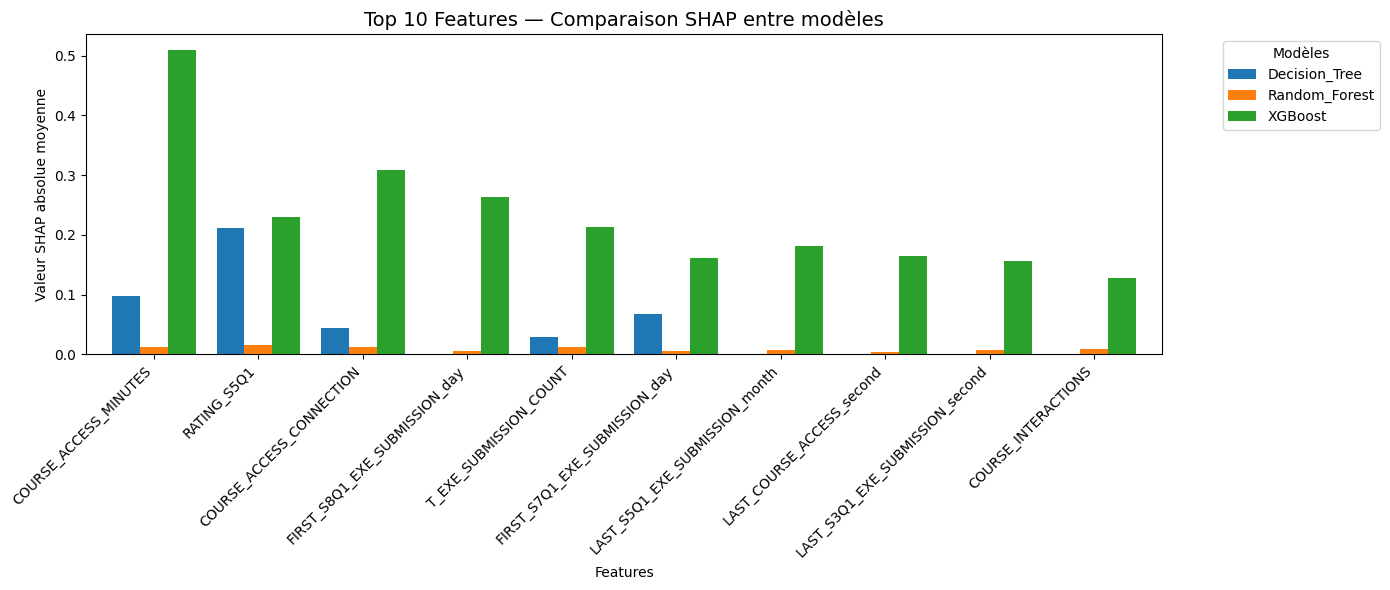


   RÉSUMÉ — Top 5 features par modèle :

   Decision_Tree :
      RATING_S5Q1                              : 0.2122
      COURSE_ACCESS_MINUTES                    : 0.0976
      FIRST_S7Q1_EXE_SUBMISSION_day            : 0.0682
      TOTAL_STUDENTS_NUMBER.3                  : 0.0570
      COURSE_ACCESS_CONNECTION                 : 0.0441

   Random_Forest :
      RATING_S5Q1                              : 0.0161
      FIRST_S5Q1_EXE_SUBMISSION_year           : 0.0150
      T_EXE_SUBMISSION_COUNT                   : 0.0129
      COURSE_ACCESS_MINUTES                    : 0.0128
      COURSE_ACCESS_CONNECTION                 : 0.0119

   XGBoost :
      COURSE_ACCESS_MINUTES                    : 0.5102
      COURSE_ACCESS_CONNECTION                 : 0.3084
      FIRST_S8Q1_EXE_SUBMISSION_day            : 0.2629
      RATING_S5Q1                              : 0.2297
      T_EXE_SUBMISSION_COUNT                   : 0.2124

 CALCUL DE LA STABILITÉ

   Modèle : Decision_Tree
   Création d

In [9]:
shap_eval = SHAPEvaluator(evaluator)
shap_eval.run()